In [1]:
import polars as pl
import pandas as pd
from indicators.types import IndicatorConfig, IndicatorType
from indicators.momento import RSIIndicator, StochasticOscillatorIndicator, CCIIndicator
from indicators.volatilidade import ATRIndicator, BollingerBandsIndicator, DonchianChannelIndicator
from indicators.tendencia import IchimokuCloudIndicator
from indicators.volume import MFIIndicator, OBVIndicator, VWAPIndicator
from indicators.medias_moveis import ADXIndicator, EMAIndicator, SMAIndicator, MACDIndicator

from data_loader.loader import DataLoader

from backtesting import Backtest, Strategy
import optuna
from optuna.exceptions import TrialPruned

import numpy as np
import gymnasium as gym
from gymnasium import spaces
from gymnasium.wrappers import TimeLimit
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import BaseCallback

import seaborn as sns
import matplotlib.pyplot as plt

/opt/conda/lib/python3.12/site-packages/backtesting/_plotting.py:55: UserWarning: Jupyter Notebook detected. Setting Bokeh output to notebook. This may not work in Jupyter clients without JavaScript support, such as old IDEs. Reset with `backtesting.set_bokeh_output(notebook=False)`.
  warnings.warn('Jupyter Notebook detected. '


Loading BokehJS ...

2025-05-16 18:47:02.436360: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-16 18:47:02.462696: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747421222.481285   97106 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747421222.486171   97106 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1747421222.507033   97106 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
df = pl.read_parquet("data/AAPL_5minute.parquet")
df.head()

open,high,low,close,volume,date
f64,f64,f64,f64,f64,datetime[ns]
77.465,77.465,77.465,77.465,6404.0,2020-05-18 08:00:00
77.5275,77.54,77.5275,77.54,3716.0,2020-05-18 08:05:00
77.55,77.55,77.55,77.55,2012.0,2020-05-18 08:10:00
77.6825,77.6825,77.6825,77.6825,1040.0,2020-05-18 08:15:00
77.6075,77.6075,77.6075,77.6075,400.0,2020-05-18 08:20:00


In [3]:
def preprocess_with_indicators(path: str, indicadores: list[IndicatorConfig]) -> pl.DataFrame:
    # 1) Lazy load + limpezas básicas (usar with_columns para tudo)
    df = (
        pl.scan_parquet(path)  # Alterado de read_parquet para scan_parquet
          .sort("date")
          .fill_null(strategy="forward")
          .fill_null(0.0)
          .with_columns([
              pl.col(c).log().alias(f"{c}_log")
              for c in ["open", "high", "low", "close"]
          ])
          .collect()
    )

    # 2) Adiciona indicadores via DataLoader
    dl = DataLoader()
    df = dl.add_technical_indicators(df, indicators_to_add=indicadores)

    # 3) Reaplica fill_null para cobrir NaNs iniciais dos indicadores
    df = df.fill_null(strategy="forward").fill_null(0.0)

    # 4) Padroniza nomes de colunas para lowercase para evitar case mismatches
    df = df.rename({col: col.lower() for col in df.columns})

    return df

Pre-processamento

In [4]:
# %%

indicadores = [
    # Momento
    IndicatorConfig(IndicatorType.RSI, params=[14]),
    IndicatorConfig(IndicatorType.STOCH, params=[14, 3]), # k_period, d_period, slowing_k_period
    IndicatorConfig(IndicatorType.CCI, params=[20]),

    # Volatilidade
    IndicatorConfig(IndicatorType.BB, params=[20, 2]), # period, num_std_devs
    IndicatorConfig(IndicatorType.DONCHIAN, params=[20]), # n_periods
    # IndicatorConfig(IndicatorType.ROC, params=[12]), # Você removeu ROCIndicator da importação

    # Tendência
    IndicatorConfig(IndicatorType.ICHIMOKU, params=[9, 26, 52]), # tenkan_sen_period, kijun_sen_period, senkou_span_b_period

    # Volume
    IndicatorConfig(IndicatorType.MFI, params=[14]), # n_periods
    IndicatorConfig(IndicatorType.OBV, params=[]),
    IndicatorConfig(IndicatorType.VWAP, params=[14]),

    # Médias Móveis
    IndicatorConfig(IndicatorType.ADX, params=[14]), # n_periods
    IndicatorConfig(IndicatorType.EMA, params=[20]), # n_periods
    IndicatorConfig(IndicatorType.SMA, params=[50]), # n_periods
    IndicatorConfig(IndicatorType.MACD, params=[12, 26, 9]) # fast_period, slow_period, signal_period
]

In [5]:
path = "/workspaces/VIII-Desafio-de-Ciencia-de-Dados/data/AAPL_5minute.parquet"
df = preprocess_with_indicators(path, indicadores)

Erro ao adicionar indicador obv: 'Expr' object has no attribute 'cumsum'


In [6]:
df

open,high,low,close,volume,date,open_log,high_log,low_log,close_log,rsi_14,stochk_14_3,stochd_14_3,cci_20,bb_middle_20,bb_upper_20,bb_lower_20,dc_upper_20,dc_lower_20,dc_middle_20,tenkan_9,kijun_26,senkou_a_9_26,senkou_b_52,chikou_26,mfi_14,vwap_14,adx_14,+di_14,-di_14,ema_20,sma_50,macd_line,macd_signal,macd_hist
f64,f64,f64,f64,f64,datetime[ns],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
77.465,77.465,77.465,77.465,6404.0,2020-05-18 08:00:00,4.349826,4.349826,4.349826,4.349826,40.240455,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,77.2525,100.0,0.0,0.125604,0.0,0.0,77.465,0.0,0.0,0.0,0.0
77.5275,77.54,77.5275,77.54,3716.0,2020-05-18 08:05:00,4.350633,4.350794,4.350633,4.350794,40.240455,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,77.235,100.0,0.0,0.125604,0.0,0.0,77.472143,0.0,0.001683,0.000935,0.000748
77.55,77.55,77.55,77.55,2012.0,2020-05-18 08:10:00,4.350923,4.350923,4.350923,4.350923,40.240455,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,77.29,100.0,0.0,0.125604,0.0,0.0,77.479558,0.0,0.002454,0.001558,0.000897
77.6825,77.6825,77.6825,77.6825,1040.0,2020-05-18 08:15:00,4.35263,4.35263,4.35263,4.35263,40.240455,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,77.3775,100.0,0.0,0.125604,0.0,0.0,77.498886,0.0,0.007529,0.00358,0.003948
77.6075,77.6075,77.6075,77.6075,400.0,2020-05-18 08:20:00,4.351664,4.351664,4.351664,4.351664,40.240455,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,77.3125,100.0,0.0,0.125604,0.0,0.0,77.50923,0.0,0.007143,0.00464,0.002503
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
126.7207,126.87,126.0625,126.1263,4.55504e6,2020-08-24 14:20:00,4.841985,4.843163,4.836778,4.837284,40.866356,28.192741,34.908636,-106.085727,127.47538,129.694242,125.256518,128.995,125.0,126.9975,126.86265,126.9975,127.743125,126.655,125.3663,31.907138,127.031971,42.810667,12.818484,27.344818,127.138308,127.725502,-0.52598,-0.33787,-0.18811
126.0775,126.125,125.7,125.7225,3.676124e6,2020-08-24 14:25:00,4.836897,4.837273,4.833898,4.834077,38.461747,18.085106,29.798081,-128.569286,127.342755,129.650518,125.034992,128.995,125.0,126.9975,126.43,126.9975,127.59125,126.6925,125.3663,30.930027,126.987622,42.716426,12.290347,29.721681,127.003469,127.709152,-0.570031,-0.384302,-0.185729
125.7048,125.9425,125.2901,125.4088,3.94402e6,2020-08-24 14:30:00,4.833936,4.835825,4.830632,4.831579,36.65719,10.232791,18.836879,-128.902403,127.19632,129.607662,124.784978,128.995,125.0,126.9975,126.0875,126.9975,127.63625,127.46375,125.3663,29.987327,126.931466,43.014191,11.508854,31.826875,126.851596,127.680478,-0.623073,-0.432056,-0.191016


In [7]:
print(df.shape)
print(df.columns)

(12237, 35)
['open', 'high', 'low', 'close', 'volume', 'date', 'open_log', 'high_log', 'low_log', 'close_log', 'rsi_14', 'stochk_14_3', 'stochd_14_3', 'cci_20', 'bb_middle_20', 'bb_upper_20', 'bb_lower_20', 'dc_upper_20', 'dc_lower_20', 'dc_middle_20', 'tenkan_9', 'kijun_26', 'senkou_a_9_26', 'senkou_b_52', 'chikou_26', 'mfi_14', 'vwap_14', 'adx_14', '+di_14', '-di_14', 'ema_20', 'sma_50', 'macd_line', 'macd_signal', 'macd_hist']


In [8]:
df.select([pl.count().alias("nulos")]).to_pandas()
df.describe().to_pandas()

/tmp/ipykernel_97106/1455035489.py:1: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
  df.select([pl.count().alias("nulos")]).to_pandas()


,statistic,open,high,low,close,volume,date,open_log,high_log,low_log,...,mfi_14,vwap_14,adx_14,+di_14,-di_14,ema_20,sma_50,macd_line,macd_signal,macd_hist
0,count,12237.000000,12237.000000,12237.000000,12237.000000,1.223700e+04,12237,12237.000000,12237.000000,12237.000000,...,12237.000000,12237.000000,12237.000000,12237.000000,12237.000000,12237.000000,12237.000000,12237.000000,12237.000000,12237.000000
1,null_count,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,mean,94.741907,94.817138,94.665434,94.744799,7.861988e+05,2020-07-06 09:55:05.295415,4.543178,4.543967,4.542375,...,52.956123,94.634650,25.745265,25.550354,24.876254,94.706643,94.334696,0.028487,0.028654,-0.000167
3,std,12.179279,12.192367,12.165911,12.180137,1.277076e+06,None,0.125314,0.125353,0.125274,...,21.200608,12.540257,11.404471,11.425178,10.644640,12.153181,13.462884,0.160207,0.151714,0.045206
4,min,77.150000,77.150000,77.117500,77.150000,4.000000e+02,2020-05-18 08:00:00,4.345752,4.345752,4.345330,...,0.650720,0.000000,0.125604,0.000000,0.000000,77.346685,0.000000,-0.711761,-0.653422,-0.346180
5,25%,85.787500,85.867500,85.717500,85.795000,1.036400e+04,2020-06-11 14:55:00,4.451873,4.452805,4.451057,...,38.175310,85.738816,17.389713,17.598803,17.701319,85.699598,85.570092,-0.046030,-0.044047,-0.021998
6,50%,92.815000,92.962500,92.745000,92.820000,8.727600e+04,2020-07-07 17:10:00,4.530608,4.532196,4.529854,...,53.162212,92.717835,23.609731,23.575316,23.130391,92.781414,92.738244,0.024428,0.024402,-0.001133
7,75%,99.442500,99.512500,99.337500,99.442500,1.207604e+06,2020-07-30 18:45:00,4.599580,4.600283,4.598523,...,67.970621,99.312133,31.562933,31.009591,30.287785,99.160764,99.005180,0.101911,0.098855,0.021448
8,max,128.762500,128.995000,128.579500,128.787500,2.500762e+07,2020-08-24 14:40:00,4.857970,4.859774,4.856547,...,100.000000,128.450586,73.881747,88.981632,81.194503,128.310313,127.811426,1.433748,1.323664,0.497855


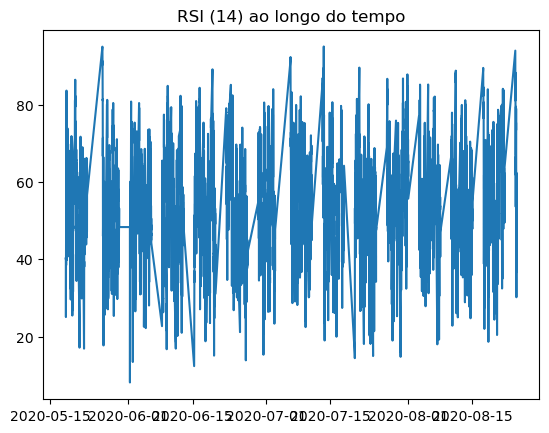

In [9]:
import matplotlib.pyplot as plt
# Convertendo para pandas antes de plotar
pdf_rsi = df.select(['date', 'rsi_14']).to_pandas()
plt.plot(pdf_rsi["date"], pdf_rsi["rsi_14"])
plt.title("RSI (14) ao longo do tempo")
plt.show()

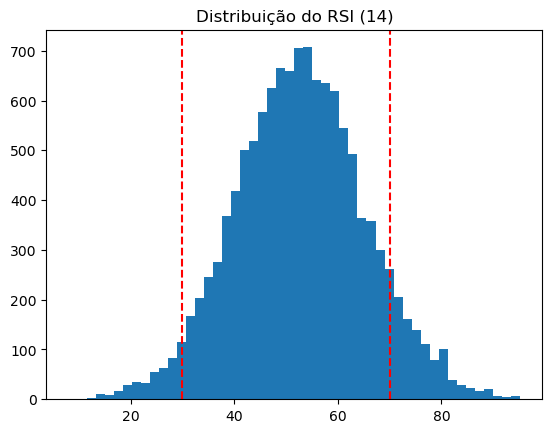

In [10]:
# Convertendo para pandas antes de plotar
pdf_rsi = df["rsi_14"].to_pandas()
plt.hist(pdf_rsi, bins=50)
plt.axvline(30, color="r", linestyle="--")
plt.axvline(70, color="r", linestyle="--")
plt.title("Distribuição do RSI (14)")
plt.show()

 O histograma mostra um RSI bem "gaussiano" em torno dos 50, com quase toda a massa entre 30 e 70 — ou seja, sinais de sobrecompra/sobrevenda (30/70) são relativamente raros.


In [11]:
total = len(df)
oversold = (df["rsi_14"] < 30).sum()
overbought = (df["rsi_14"] > 70).sum()

print(f"Oversold (<30): {oversold} barras — {oversold/total:.2%}")
print(f"Overbought (>70): {overbought} barras — {overbought/total:.2%}")

Oversold (<30): 390 barras — 3.19%
Overbought (>70): 1044 barras — 8.53%


 Tentando suavizar o RSI

In [12]:
df = df.with_columns([
    pl.col("rsi_14")
      .rolling_mean(window_size=5)
      .alias("RSI_smooth")
])

In [13]:
total = len(df)
os_s = (df["RSI_smooth"] < 30).sum()
ob_s = (df["RSI_smooth"] > 70).sum()
print(f"Oversold_smooth: {os_s} barras — {os_s/total:.2%}")
print(f"Overbought_smooth: {ob_s} barras — {ob_s/total:.2%}")

Oversold_smooth: 284 barras — 2.32%
Overbought_smooth: 941 barras — 7.69%


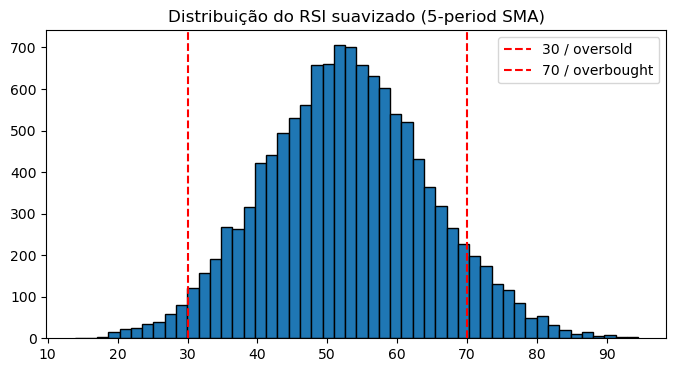

In [14]:
import matplotlib.pyplot as plt

rsi_s = df["RSI_smooth"].to_pandas()

plt.figure(figsize=(8,4))
plt.hist(rsi_s, bins=50, edgecolor="k")
plt.axvline(30, color="r", linestyle="--", label="30 / oversold")
plt.axvline(70, color="r", linestyle="--", label="70 / overbought")
plt.title("Distribuição do RSI suavizado (5-period SMA)")
plt.legend()
plt.show()

In [15]:
# --- Função de backtest para indicadores --- #
def backtest_indicators(df, indicators):
    """
    Função para backtest de estratégias baseadas em indicadores técnicos.

    Args:
        df: DataFrame (pandas ou polars) com dados OHLCV
        indicators: dicionário de indicadores com thresholds de compra/venda

    Returns:
        pandas DataFrame com resultados do backtest
    """
    results = []

    # Garantir que estamos trabalhando com pandas DataFrame
    if not isinstance(df, pd.DataFrame):
        print("Convertendo Polars DataFrame para pandas DataFrame...")
        df = df.to_pandas()

    # Renomear colunas para padrão do Backtest
    df_bt = df.rename(columns={'open':'Open','high':'High','low':'Low','close':'Close'}) \
              .dropna(subset=['Open','High','Low','Close'])

    class IndicatorStrategy(Strategy):
        def init(self):
            self.ind = self.I(lambda d: d[self.name], self.data.df)
        def next(self):
            if not self.position and self.ind[-1] < self.buy_thr:
                self.buy()
            elif self.position and self.ind[-1] > self.sell_thr:
                self.position.close()

    for name, thr in indicators.items():
        Strat = type(f"Strat_{name}", (IndicatorStrategy,),
                     {"name": name, "buy_thr": thr['buy_thr'], "sell_thr": thr['sell_thr']})
        bt = Backtest(df_bt, Strat, cash=100_000, commission=0.001, trade_on_close=True)
        stats = bt.run()
        bt.plot()  # Adicionado para plotar o gráfico da estratégia
        results.append({
            'indicator': name,
            'Return [%]': stats['Return [%]'],
            'Sharpe': stats['Sharpe Ratio']
        })
    return pd.DataFrame(results).set_index('indicator')

 # Análise de Correlação entre Indicadores

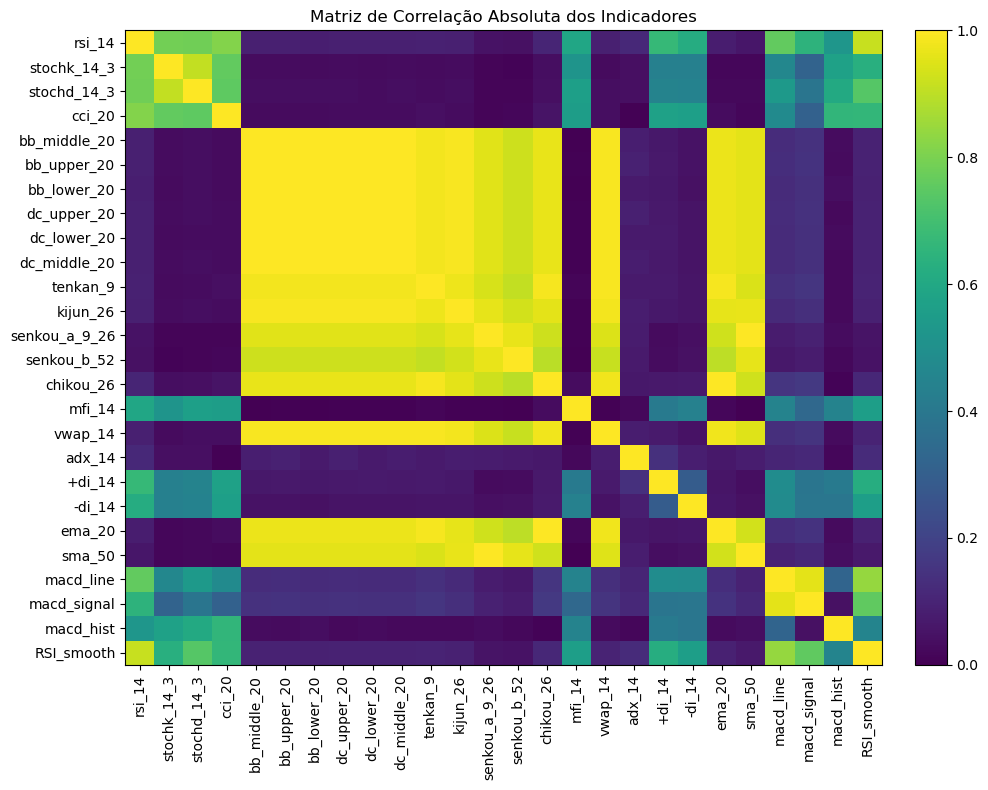


73 pares com |corr| > 0.95:
             feat1          feat2      corr
98   bb_middle_20   dc_middle_20  0.999885
116   bb_upper_20    dc_upper_20  0.999878
155   dc_upper_20   dc_middle_20  0.999705
172   dc_lower_20   dc_middle_20  0.999699
96   bb_middle_20    dc_upper_20  0.999687
..            ...            ...       ...
191  dc_middle_20  senkou_a_9_26  0.955179
140   bb_lower_20  senkou_a_9_26  0.955155
175   dc_lower_20  senkou_a_9_26  0.954933
158   dc_upper_20  senkou_a_9_26  0.954855
121   bb_upper_20  senkou_a_9_26  0.954666

[73 rows x 3 columns]
Colunas removidas: ['dc_middle_20', 'dc_upper_20', 'bb_upper_20', 'bb_lower_20', 'dc_lower_20', 'ema_20', 'sma_50', 'vwap_14', 'kijun_26', 'chikou_26', 'tenkan_9', 'senkou_b_52', 'senkou_a_9_26', 'macd_signal']
Forma original: (12237, 36)
Forma reduzida: (12237, 22)


In [16]:
# %%

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 1) Lista de colunas de indicador, como antes
exclude = {
    'open','high','low','close','volume','date',
    'open_log','high_log','low_log','close_log'
}
ind_cols = [c for c in df.columns if c not in exclude]

# --- 2) Converta só o pedaço de indicadores para pandas
pdf_ind = df[ind_cols].to_pandas()

# --- 3) Calcule correlação absoluta
corr = pdf_ind.corr().abs()

# --- 4) Plote o heatmap
plt.figure(figsize=(max(10, corr.shape[1]*0.3), max(8, corr.shape[0]*0.3)))
plt.imshow(corr, vmin=0, vmax=1, aspect='auto')
plt.colorbar(fraction=0.046, pad=0.04)
plt.xticks(range(len(corr)), corr.columns, rotation=90)
plt.yticks(range(len(corr)), corr.index)
plt.title("Matriz de Correlação Absoluta dos Indicadores")
plt.tight_layout()
plt.show()

# --- 5) Extraia pares com |corr| > thresh
thresh = 0.95
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
high_corr = (
    corr.where(mask)         # zera abaixo da diagonal
        .stack()             # empilha (i,j) e valor
        .reset_index(name='corr')
        .rename(columns={'level_0':'feat1','level_1':'feat2'})
)
high_corr = high_corr[high_corr['corr'] > thresh] \
            .sort_values('corr', ascending=False)

print(f"\n{len(high_corr)} pares com |corr| > {thresh}:\n", high_corr)

# --- 6) Drop automático das segundas colunas de cada par
# supondo que `to_drop` é um set ou lista de strings
cols_to_drop = high_corr['feat2'].unique().tolist()  # pega cada indicador redundante apenas uma vez

# abordagem 1: usando Polars .drop()
df_reduzido = df.drop(cols_to_drop)

# OU, se preferir via select:
# df_reduzido = df.select([c for c in df.columns if c not in cols_to_drop])

print("Colunas removidas:", cols_to_drop)
print("Forma original:", df.shape)
print("Forma reduzida:", df_reduzido.shape)

In [17]:
# Primeiro, vamos imprimir os nomes exatos das colunas de indicadores para referência
print("Nomes exatos das colunas de indicadores:")
indicator_columns = [col for col in df.columns if col not in ['date', 'open', 'high', 'low', 'close', 'volume',
                                                         'open_log', 'high_log', 'low_log', 'close_log']]
print(indicator_columns)

Nomes exatos das colunas de indicadores:
['rsi_14', 'stochk_14_3', 'stochd_14_3', 'cci_20', 'bb_middle_20', 'bb_upper_20', 'bb_lower_20', 'dc_upper_20', 'dc_lower_20', 'dc_middle_20', 'tenkan_9', 'kijun_26', 'senkou_a_9_26', 'senkou_b_52', 'chikou_26', 'mfi_14', 'vwap_14', 'adx_14', '+di_14', '-di_14', 'ema_20', 'sma_50', 'macd_line', 'macd_signal', 'macd_hist', 'RSI_smooth']


In [18]:
# Exemplo de comparação – usando nomes de colunas exatos em minúsculas
indicator_thresholds = {
    'rsi_14':    {'buy_thr': 30,  'sell_thr': 70},
    'cci_20':    {'buy_thr': -100,'sell_thr': 100},
    # Use os nomes exatos das colunas aqui, conforme o print acima
}

# 1) Converte todo o Polars DataFrame original pra pandas
pdf_full = df.to_pandas()
pdf_full['date'] = pd.to_datetime(pdf_full['date'])
pdf_full.set_index('date', inplace=True)

# 2) Converte também o df_reduzido
pdf_reduced = df_reduzido.to_pandas()
pdf_reduced['date'] = pd.to_datetime(pdf_reduced['date'])
pdf_reduced.set_index('date', inplace=True)

# 3) Agora chame backtest_indicators usando esses pandas DataFrames
summary_full    = backtest_indicators(pdf_full,    indicator_thresholds)
#summary_reduced = backtest_indicators(pdf_reduced, indicator_thresholds)

print("=== Backtest Completo ===")
print(summary_full)
#print("\n=== Backtest Reduzido ===")
#print(summary_reduced)

Backtest.run:   0%|          | 0/12236 [00:00<?, ?bar/s]

/opt/conda/lib/python3.12/site-packages/backtesting/_plotting.py:141: UserWarning: Data contains too many candlesticks to plot; downsampling to '15min'. See `Backtest.plot(resample=...)`
  warnings.warn(f"Data contains too many candlesticks to plot; downsampling to {freq!r}. "


Backtest.run:   0%|          | 0/12236 [00:00<?, ?bar/s]

/opt/conda/lib/python3.12/site-packages/backtesting/_plotting.py:141: UserWarning: Data contains too many candlesticks to plot; downsampling to '15min'. See `Backtest.plot(resample=...)`
  warnings.warn(f"Data contains too many candlesticks to plot; downsampling to {freq!r}. "


=== Backtest Completo ===
           Return [%]    Sharpe
indicator                      
rsi_14       7.138645  1.145254
cci_20     -16.958402 -5.353382


 # Treinamento DRL

In [19]:
df_reduzido.columns

['open',
 'high',
 'low',
 'close',
 'volume',
 'date',
 'open_log',
 'high_log',
 'low_log',
 'close_log',
 'rsi_14',
 'stochk_14_3',
 'stochd_14_3',
 'cci_20',
 'bb_middle_20',
 'mfi_14',
 'adx_14',
 '+di_14',
 '-di_14',
 'macd_line',
 'macd_hist',
 'RSI_smooth']

In [20]:
df = df_reduzido.to_pandas()
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)
df_reduzido = df_reduzido.with_columns(pl.col("RSI_smooth")
                                       .fill_null(strategy="forward")
                                        .fill_null(strategy="backward"))
df

,open,high,low,close,volume,open_log,high_log,low_log,close_log,rsi_14,...,stochd_14_3,cci_20,bb_middle_20,mfi_14,adx_14,+di_14,-di_14,macd_line,macd_hist,RSI_smooth
date,,,,,,,,,,,,,,,,,,,,,
2020-05-18 08:00:00,77.4650,77.4650,77.4650,77.4650,6404.0,4.349826,4.349826,4.349826,4.349826,40.240455,...,0.000000,0.000000,0.000000,100.000000,0.125604,0.000000,0.000000,0.000000,0.000000,NaN
2020-05-18 08:05:00,77.5275,77.5400,77.5275,77.5400,3716.0,4.350633,4.350794,4.350633,4.350794,40.240455,...,0.000000,0.000000,0.000000,100.000000,0.125604,0.000000,0.000000,0.001683,0.000748,NaN
2020-05-18 08:10:00,77.5500,77.5500,77.5500,77.5500,2012.0,4.350923,4.350923,4.350923,4.350923,40.240455,...,0.000000,0.000000,0.000000,100.000000,0.125604,0.000000,0.000000,0.002454,0.000897,NaN
2020-05-18 08:15:00,77.6825,77.6825,77.6825,77.6825,1040.0,4.352630,4.352630,4.352630,4.352630,40.240455,...,0.000000,0.000000,0.000000,100.000000,0.125604,0.000000,0.000000,0.007529,0.003948,NaN
2020-05-18 08:20:00,77.6075,77.6075,77.6075,77.6075,400.0,4.351664,4.351664,4.351664,4.351664,40.240455,...,0.000000,0.000000,0.000000,100.000000,0.125604,0.000000,0.000000,0.007143,0.002503,40.240455
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-08-24 14:20:00,126.7207,126.8700,126.0625,126.1263,4555040.0,4.841985,4.843163,4.836778,4.837284,40.866356,...,34.908636,-106.085727,127.475380,31.907138,42.810667,12.818484,27.344818,-0.525980,-0.188110,38.778335
2020-08-24 14:25:00,126.0775,126.1250,125.7000,125.7225,3676124.0,4.836897,4.837273,4.833898,4.834077,38.461747,...,29.798081,-128.569286,127.342755,30.930027,42.716426,12.290347,29.721681,-0.570031,-0.185729,39.698631
2020-08-24 14:30:00,125.7048,125.9425,125.2901,125.4088,3944020.0,4.833936,4.835825,4.830632,4.831579,36.657190,...,18.836879,-128.902403,127.196320,29.987327,43.014191,11.508854,31.826875,-0.623073,-0.191016,40.412758


In [21]:

feature_names = [
    'close', 'volume',
    'rsi_14',
    'stochk_14_3',
    'stochd_14_3',
    'cci_20',
    'bb_middle_20',
    'mfi_14',
    'adx_14',
    '+di_14',
    '-di_14',
    'macd_line',
    'macd_hist',
    'RSI_smooth'
]

In [22]:
from env.trading_env import CustomTradingEnv

def make_env(df):
    def _init():
        return CustomTradingEnv(df, features=feature_names, window_size=20)
    return _init

In [23]:
print(f"Colunas em df_reduzido para DRL: {df_reduzido.columns}")

train_ratio = 0.8
n_total_rows = df_reduzido.height # Usar .height para Polars
n_train_rows = int(n_total_rows * train_ratio)

# Divide o DataFrame Polars
df_train_pl = df_reduzido.slice(0, n_train_rows)
df_test_pl = df_reduzido.slice(n_train_rows, n_total_rows - n_train_rows) # O segundo argumento é o tamanho

print(f"Total de linhas no df_reduzido: {n_total_rows}")
print(f"Linhas de treino (Polars): {df_train_pl.height}")
print(f"Linhas de teste (Polars): {df_test_pl.height}")

Colunas em df_reduzido para DRL: ['open', 'high', 'low', 'close', 'volume', 'date', 'open_log', 'high_log', 'low_log', 'close_log', 'rsi_14', 'stochk_14_3', 'stochd_14_3', 'cci_20', 'bb_middle_20', 'mfi_14', 'adx_14', '+di_14', '-di_14', 'macd_line', 'macd_hist', 'RSI_smooth']
Total de linhas no df_reduzido: 12237
Linhas de treino (Polars): 9789
Linhas de teste (Polars): 2448


In [24]:
train_env_initializer = make_env(df_train_pl)
test_env_initializer = make_env(df_test_pl)

print("Inicializadores de ambiente de treino e teste para DRL foram criados.")

Inicializadores de ambiente de treino e teste para DRL foram criados.


In [25]:
pdf = df_reduzido.to_pandas()
pdf['date'] = pd.to_datetime(pdf['date'])
pdf.set_index('date', inplace=True)

split_idx = int(len(pdf) * 0.8)
train_df_pd = pdf.iloc[:split_idx]
test_df_pd  = pdf.iloc[split_idx:]

# Adiciona colunas uppercase necessárias para o backtesting.py (mantém lowercase para RL)
test_df_pd['Open']  = test_df_pd['open']
test_df_pd['High']  = test_df_pd['high']
test_df_pd['Low']   = test_df_pd['low']
test_df_pd['Close'] = test_df_pd['close']

/tmp/ipykernel_97106/2349705907.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df_pd['Open']  = test_df_pd['open']
/tmp/ipykernel_97106/2349705907.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df_pd['High']  = test_df_pd['high']
/tmp/ipykernel_97106/2349705907.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-d

In [26]:
def make_env_optuna(df_input: pd.DataFrame, window_size: int = 20, fee: float = 0.001):

    df_polars = pl.from_pandas(df_input.reset_index()) # Converte para Polars

    def _init():
        env = CustomTradingEnv(df_polars, features=feature_names, window_size=window_size, fee=fee)
        return TimeLimit(env, max_episode_steps=df_polars.height - window_size)

    return _init

In [27]:
"""class TensorboardCallback(BaseCallback):
    def __init__(self, eval_freq: int, eval_env=None, n_eval_episodes: int = 5, verbose: int = 0):
        super().__init__(verbose)
        self.eval_freq = eval_freq  # Armazena eval_freq
        # Se esta callback for realizar sua própria avaliação para logar,
        # você também precisará do eval_env e n_eval_episodes.
        self.eval_env = eval_env
        self.n_eval_episodes = n_eval_episodes

    def _on_step(self) -> bool:
        if self.n_calls % self.eval_freq == 0: # Usa self.eval_freq
            if self.eval_env is not None:
                # Se esta callback deve fazer sua própria avaliação:
                # mean_reward, _ = evaluate_policy(self.model, self.eval_env, n_eval_episodes=self.n_eval_episodes, deterministic=True)
                # self.logger.record("custom_eval/mean_reward", mean_reward)
                # print(f"TensorboardCallback: Eval @ step {self.n_calls}, Mean reward: {mean_reward}")
                pass # Remova o 'pass' e descomente/implemente a lógica de avaliação e log acima se necessário.
            else:
                # Se esta callback loga outras coisas ou você espera que 'mean_reward' venha de outro lugar.
                # A linha 'mean_reward = ... # cálculo' no seu traceback indica que o cálculo está pendente.
                # Por agora, vamos apenas resolver o NameError.
                if self.verbose > 0:
                    print(f"TensorboardCallback: _on_step called at {self.n_calls} (eval_freq: {self.eval_freq}). Implement logging logic.")
        return True"""

'class TensorboardCallback(BaseCallback):\n    def __init__(self, eval_freq: int, eval_env=None, n_eval_episodes: int = 5, verbose: int = 0):\n        super().__init__(verbose)\n        self.eval_freq = eval_freq  # Armazena eval_freq\n        # Se esta callback for realizar sua própria avaliação para logar,\n        # você também precisará do eval_env e n_eval_episodes.\n        self.eval_env = eval_env\n        self.n_eval_episodes = n_eval_episodes\n\n    def _on_step(self) -> bool:\n        if self.n_calls % self.eval_freq == 0: # Usa self.eval_freq\n            if self.eval_env is not None:\n                # Se esta callback deve fazer sua própria avaliação:\n                # mean_reward, _ = evaluate_policy(self.model, self.eval_env, n_eval_episodes=self.n_eval_episodes, deterministic=True)\n                # self.logger.record("custom_eval/mean_reward", mean_reward)\n                # print(f"TensorboardCallback: Eval @ step {self.n_calls}, Mean reward: {mean_reward}")\n      

In [28]:
class OptunaCallback(BaseCallback):
    def __init__(self, trial: optuna.Trial, eval_env: VecNormalize, n_eval_episodes: int = 5, eval_freq: int = 1000, verbose: int = 0):
        super().__init__(verbose)
        self.trial = trial
        self.eval_env = eval_env
        self.n_eval_episodes = n_eval_episodes
        self.eval_freq = eval_freq
        self.best_mean_reward = -float('inf')

    def _on_step(self) -> bool:
        if self.n_calls % self.eval_freq == 0:
            # Usar return_episode_rewards=True para obter a lista de recompensas
            episode_rewards, _ = evaluate_policy(
                self.model,
                self.eval_env,
                n_eval_episodes=self.n_eval_episodes,
                deterministic=True,
                return_episode_rewards=True
                # O warning sobre Monitor não deve aparecer aqui se eval_env já tem Monitor
            )
            # Calcular média e desvio padrão manualmente
            mean_reward = np.mean(episode_rewards)
            std_reward = np.std(episode_rewards)

            if self.verbose > 0:
                print(f"Eval @ step {self.n_calls}: Mean reward: {mean_reward:.2f} +/- {std_reward:.2f}")

            # Reporta a métrica para o Optuna
            self.trial.report(mean_reward, self.n_calls)

            # Pruning (interrompe o trial se não estiver melhorando)
            if self.trial.should_prune():
                if self.verbose > 0:
                    print("Trial pruned by Optuna.")
                raise TrialPruned()

            # Opcional: salvar o melhor modelo intermediário do trial
            if mean_reward > self.best_mean_reward:
                self.best_mean_reward = mean_reward
                # self.model.save(f"trial_{self.trial.number}_best_model_step_{self.n_calls}")
        return True

In [29]:
import os

def objective(trial: optuna.Trial) -> float:
    # --- Hiperparâmetros a buscar ---
    n_steps         = trial.suggest_categorical('n_steps', [128, 256, 512, 1024])
    gamma           = trial.suggest_float('gamma', 0.90, 0.9999, log=True)
    learning_rate   = trial.suggest_float('learning_rate', 1e-5, 1e-3, log=True)
    ent_coef        = trial.suggest_float('ent_coef', 1e-8, 1e-1, log=True) # Aumentei um pouco o limite superior
    batch_size      = trial.suggest_categorical('batch_size', [64, 128, 256])

    # Novos hiperparâmetros sugeridos
    vf_coef         = trial.suggest_float("vf_coef", 0.1, 1.0)
    max_grad_norm   = trial.suggest_float("max_grad_norm", 0.3, 5.0)
    clip_range      = trial.suggest_float("clip_range", 0.1, 0.4)
    norm_reward_train = trial.suggest_categorical('norm_reward_train', [True, False])
    gae_lambda      = trial.suggest_float("gae_lambda", 0.9, 0.999)

    # Sugerir arquitetura de rede
    net_arch_choice = trial.suggest_categorical("net_arch", ["small", "medium"])
    if net_arch_choice == "small":
        policy_kwargs = dict(net_arch=dict(pi=[64, 64], vf=[64, 64]))
    else: # medium
        policy_kwargs = dict(net_arch=dict(pi=[128, 128], vf=[128, 128]))

     # --- Criação de diretórios de log para o Monitor ---
    log_dir_base = "./monitor_logs_optuna" # Diretório base para todos os logs de monitoramento
    trial_log_dir = os.path.join(log_dir_base, f"trial_{trial.number}")
    os.makedirs(trial_log_dir, exist_ok=True)

    train_monitor_path = os.path.join(trial_log_dir, "train") # Monitor adiciona .monitor.csv
    eval_monitor_path = os.path.join(trial_log_dir, "eval")   # Monitor adiciona .monitor.csv


    # --- Cria ambientes vetorizados ---
    # Ambiente de Treino
    # Assegure que make_env_optuna retorna uma função lambda: YourEnv(df)
    train_env_callable = make_env_optuna(train_df_pd)
    train_env_monitored_callable = lambda: Monitor(train_env_callable(), filename=train_monitor_path, allow_early_resets=True)
    train_env_raw = DummyVecEnv([train_env_monitored_callable])

    # Envolver com Monitor ANTES de VecNormalize se quiser logar recompensas não normalizadas
    # train_env_monitored = DummyVecEnv([lambda: Monitor(train_env_callable())])
    train_env = VecNormalize(train_env_raw, norm_obs=True, norm_reward=norm_reward_train, training=True, gamma=gamma)


    # Ambiente de Avaliação
    eval_env_callable = make_env_optuna(test_df_pd)
    # Envolver com Monitor para avaliação correta
    eval_env_monitored_callable = lambda: Monitor(eval_env_callable(), filename=eval_monitor_path, allow_early_resets=True)
    eval_env_raw = DummyVecEnv([eval_env_monitored_callable])
    eval_env = VecNormalize(eval_env_raw, norm_obs=True, norm_reward=False, training=False, gamma=gamma)
    # Sincronizar estatísticas do train_env para eval_env ANTES da avaliação e do callback
    eval_env.obs_rms = train_env.obs_rms # Copia obs_rms
    # eval_env.ret_rms = train_env.ret_rms # Não copie ret_rms se norm_reward_train=True e eval_env.norm_reward=False

    # --- Callback para Optuna Pruning ---
    # Aumentando n_eval_episodes e ajustando eval_freq
    # total_timesteps_learn é o total de passos para model.learn
    total_timesteps_learn = 50_000
    eval_freq_callback = max(1, total_timesteps_learn // 20) # Avalia ~10 vezes durante o treino
    n_eval_episodes_callback = 10

    optuna_callback = OptunaCallback(
        trial,
        eval_env, # Passa o ambiente de avaliação normalizado
        n_eval_episodes=n_eval_episodes_callback,
        eval_freq=eval_freq_callback, # Frequência de avaliação dentro do learn
        verbose=0 # Defina para 1 para ver logs do callback
    )

    # --- Instância e treino do PPO ---
    model = PPO(
        "MlpPolicy",
        train_env,
        n_steps=n_steps,
        gamma=gamma,
        learning_rate=learning_rate,
        ent_coef=ent_coef,
        batch_size=batch_size,
        vf_coef=vf_coef,
        max_grad_norm=max_grad_norm,
        clip_range=clip_range,
        gae_lambda=gae_lambda,
        policy_kwargs=policy_kwargs,
        tensorboard_log="./tb_logs/",
        verbose=1
    )

    try:
        model.learn(total_timesteps=total_timesteps_learn, callback=[optuna_callback])
    except TrialPruned:
        # Se o trial foi interrompido pelo callback, propaga a exceção
        # para que o Optuna saiba que foi podado.
        train_env.close()
        eval_env.close()
        raise
    except Exception as e:
        # Em caso de outros erros, feche os ambientes e levante a exceção
        print(f"An error occurred during model training: {e}")
        train_env.close()
        eval_env.close()
        raise

    # --- Avalia política no ambiente de teste após o treino completo ---
    # Sincronizar estatísticas do train_env para eval_env novamente caso tenham mudado
    eval_env.obs_rms = train_env.obs_rms
    # eval_env.ret_rms = train_env.ret_rms # Cuidado aqui

    n_eval_episodes_final = 10
    # Usar return_episode_rewards=True para obter a lista de recompensas
    episode_rewards, _ = evaluate_policy(
        model,
        eval_env, # Usar o ambiente de avaliação normalizado e com Monitor
        n_eval_episodes=n_eval_episodes_final,
        deterministic=True,
        return_episode_rewards=True
    )
    # Calcular média e desvio padrão manualmente
    mean_reward = np.mean(episode_rewards)
    std_reward = np.std(episode_rewards)

    # Log de estatísticas (opcional)
    if hasattr(train_env, 'obs_rms') and train_env.obs_rms is not None:
        trial.set_user_attr("train_obs_rms_mean", float(train_env.obs_rms.mean.mean()))
        trial.set_user_attr("train_obs_rms_var_mean", float(train_env.obs_rms.var.mean()))

    # Opcionalmente, adicionar o desvio padrão como user attribute
    trial.set_user_attr("eval_reward_std", float(std_reward))

    train_env.close() # Fechar ambientes
    eval_env.close()

    # Optuna vai maximizar esse valor
    # Se quiser usar avg - k*std: return mean_reward - (k * std_reward)
    return mean_reward

In [30]:
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)
# study.optimize retorna None, então não devemos atribuir seu retorno a uma variável
study.optimize(objective, n_trials=100)

print("✔️ Melhor conjunto de parâmetros:")
print(study.best_params)
print(f"✔️ Recompensa média obtida: {study.best_value:.2f}")

[I 2025-05-16 18:47:11,676] A new study created in memory with name: no-name-20affd30-c600-4bc5-9bd7-6ddb8adc760b


Using cpu device
Logging to ./tb_logs/PPO_634
-----------------------------
| time/              |      |
|    fps             | 2183 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 256  |
-----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 1527        |
|    iterations           | 2           |
|    time_elapsed         | 0           |
|    total_timesteps      | 512         |
| train/                  |             |
|    approx_kl            | 4.78921e-05 |
|    clip_fraction        | 0           |
|    clip_range           | 0.35        |
|    entropy_loss         | -1.1        |
|    explained_variance   | -4.14       |
|    learning_rate        | 2.05e-05    |
|    loss                 | 0.00839     |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.00145    |
|    value_loss           | 0.145       |
------------------------------

[I 2025-05-16 18:50:05,701] Trial 0 finished with value: 2.0000000000000003e-06 and parameters: {'n_steps': 256, 'gamma': 0.9149023745380911, 'learning_rate': 2.0511104188433963e-05, 'ent_coef': 2.5502648504032812e-08, 'batch_size': 64, 'vf_coef': 0.1185260448662222, 'max_grad_norm': 4.858576305161374, 'clip_range': 0.34973279224012654, 'norm_reward_train': True, 'gae_lambda': 0.91815704647549, 'net_arch': 'medium'}. Best is trial 0 with value: 2.0000000000000003e-06.


Using cpu device
Logging to ./tb_logs/PPO_635
-----------------------------
| time/              |      |
|    fps             | 1965 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 512  |
-----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 1582          |
|    iterations           | 2             |
|    time_elapsed         | 0             |
|    total_timesteps      | 1024          |
| train/                  |               |
|    approx_kl            | 0.00012951088 |
|    clip_fraction        | 0             |
|    clip_range           | 0.282         |
|    entropy_loss         | -1.1          |
|    explained_variance   | -241          |
|    learning_rate        | 5.4e-05       |
|    loss                 | 0.0232        |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.0017       |
|    value_loss           | 0.15        

[I 2025-05-16 18:52:50,213] Trial 1 finished with value: 1.8e-05 and parameters: {'n_steps': 512, 'gamma': 0.9281061000627608, 'learning_rate': 5.4041038546473305e-05, 'ent_coef': 1.5577217702692994e-05, 'batch_size': 64, 'vf_coef': 0.6331731119758383, 'max_grad_norm': 0.5183169397839893, 'clip_range': 0.28226345557043153, 'norm_reward_train': True, 'gae_lambda': 0.99393966818808, 'net_arch': 'small'}. Best is trial 1 with value: 1.8e-05.


Using cpu device
Logging to ./tb_logs/PPO_636
-----------------------------
| time/              |      |
|    fps             | 2051 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 512  |
-----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 1643        |
|    iterations           | 2           |
|    time_elapsed         | 0           |
|    total_timesteps      | 1024        |
| train/                  |             |
|    approx_kl            | 0.001228198 |
|    clip_fraction        | 0           |
|    clip_range           | 0.264       |
|    entropy_loss         | -1.1        |
|    explained_variance   | -33.5       |
|    learning_rate        | 9.78e-05    |
|    loss                 | -0.00132    |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.00478    |
|    value_loss           | 0.0863      |
------------------------------

[I 2025-05-16 18:55:34,385] Trial 2 finished with value: -0.00026600000000000007 and parameters: {'n_steps': 512, 'gamma': 0.9116358018533885, 'learning_rate': 9.7803370166594e-05, 'ent_coef': 1.7406828393128058e-08, 'batch_size': 64, 'vf_coef': 0.3805399684804699, 'max_grad_norm': 2.7443196995357106, 'clip_range': 0.26401308380298394, 'norm_reward_train': False, 'gae_lambda': 0.9767381495127503, 'net_arch': 'small'}. Best is trial 1 with value: 1.8e-05.


Using cpu device
Logging to ./tb_logs/PPO_637
-----------------------------
| time/              |      |
|    fps             | 1781 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 256  |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 1661         |
|    iterations           | 2            |
|    time_elapsed         | 0            |
|    total_timesteps      | 512          |
| train/                  |              |
|    approx_kl            | 3.528362e-05 |
|    clip_fraction        | 0            |
|    clip_range           | 0.142        |
|    entropy_loss         | -1.1         |
|    explained_variance   | -6.86        |
|    learning_rate        | 4.47e-05     |
|    loss                 | 0.0753       |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00128     |
|    value_loss           | 0.292        |
-------------

[I 2025-05-16 18:58:14,873] Trial 3 finished with value: 0.11268199999999999 and parameters: {'n_steps': 256, 'gamma': 0.9042947976713407, 'learning_rate': 4.473636174621264e-05, 'ent_coef': 5.257036929213663e-06, 'batch_size': 128, 'vf_coef': 0.3528410587186427, 'max_grad_norm': 2.850671590843768, 'clip_range': 0.1422772674924288, 'norm_reward_train': True, 'gae_lambda': 0.9977018067234512, 'net_arch': 'small'}. Best is trial 3 with value: 0.11268199999999999.


Using cpu device
Logging to ./tb_logs/PPO_638
-----------------------------
| time/              |      |
|    fps             | 1850 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 256  |
-----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 1681          |
|    iterations           | 2             |
|    time_elapsed         | 0             |
|    total_timesteps      | 512           |
| train/                  |               |
|    approx_kl            | 1.3755634e-06 |
|    clip_fraction        | 0             |
|    clip_range           | 0.193         |
|    entropy_loss         | -1.1          |
|    explained_variance   | -1.6          |
|    learning_rate        | 1.41e-05      |
|    loss                 | 0.0703        |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.000246     |
|    value_loss           | 0.194       

[I 2025-05-16 19:00:57,327] Trial 4 finished with value: 0.10640800000000002 and parameters: {'n_steps': 256, 'gamma': 0.976113698381451, 'learning_rate': 1.4063366777718176e-05, 'ent_coef': 3.230428252240957e-06, 'batch_size': 128, 'vf_coef': 0.39780822236738433, 'max_grad_norm': 0.5987242463443111, 'clip_range': 0.19329469651469866, 'norm_reward_train': False, 'gae_lambda': 0.9631181896641661, 'net_arch': 'small'}. Best is trial 3 with value: 0.11268199999999999.


Using cpu device
Logging to ./tb_logs/PPO_639
-----------------------------
| time/              |      |
|    fps             | 2028 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 512  |
-----------------------------
-------------------------------------------------
| time/                   |                     |
|    fps                  | 4611686018427387904 |
|    iterations           | 2                   |
|    time_elapsed         | 0                   |
|    total_timesteps      | 1024                |
| train/                  |                     |
|    approx_kl            | 0.002537833         |
|    clip_fraction        | 0.000195            |
|    clip_range           | 0.194               |
|    entropy_loss         | -1.1                |
|    explained_variance   | -0.778              |
|    learning_rate        | 9.72e-05            |
|    loss                 | -0.00683            |
|    n_updates            | 10              

[I 2025-05-16 19:01:04,209] Trial 5 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_640
-----------------------------
| time/              |      |
|    fps             | 2100 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 512  |
-----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 1563        |
|    iterations           | 2           |
|    time_elapsed         | 0           |
|    total_timesteps      | 1024        |
| train/                  |             |
|    approx_kl            | 0.038437627 |
|    clip_fraction        | 0.122       |
|    clip_range           | 0.342       |
|    entropy_loss         | -1.08       |
|    explained_variance   | -4.81       |
|    learning_rate        | 0.000413    |
|    loss                 | -0.0633     |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.0525     |
|    value_loss           | 0.0236      |
------------------------------

[I 2025-05-16 19:01:12,748] Trial 6 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_641
-----------------------------
| time/              |      |
|    fps             | 1825 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 256  |
-----------------------------
--------------------------------------------
| time/                   |                |
|    fps                  | 1644           |
|    iterations           | 2              |
|    time_elapsed         | 0              |
|    total_timesteps      | 512            |
| train/                  |                |
|    approx_kl            | 1.11199915e-05 |
|    clip_fraction        | 0              |
|    clip_range           | 0.209          |
|    entropy_loss         | -1.1           |
|    explained_variance   | -1.34          |
|    learning_rate        | 2.78e-05       |
|    loss                 | 0.0884         |
|    n_updates            | 10             |
|    policy_gradient_loss | -0.000722      |
|    value_loss         

[I 2025-05-16 19:01:21,064] Trial 7 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_642
-----------------------------
| time/              |      |
|    fps             | 1978 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 512  |
-----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 1816          |
|    iterations           | 2             |
|    time_elapsed         | 0             |
|    total_timesteps      | 1024          |
| train/                  |               |
|    approx_kl            | 9.3579176e-05 |
|    clip_fraction        | 0             |
|    clip_range           | 0.302         |
|    entropy_loss         | -1.1          |
|    explained_variance   | -19.9         |
|    learning_rate        | 3.61e-05      |
|    loss                 | 0.0917        |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.00149      |
|    value_loss           | 0.159       

[I 2025-05-16 19:01:27,419] Trial 8 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_643
-----------------------------
| time/              |      |
|    fps             | 2139 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 1024 |
-----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 1888          |
|    iterations           | 2             |
|    time_elapsed         | 1             |
|    total_timesteps      | 2048          |
| train/                  |               |
|    approx_kl            | 2.1149172e-05 |
|    clip_fraction        | 0             |
|    clip_range           | 0.294         |
|    entropy_loss         | -1.1          |
|    explained_variance   | -7.03         |
|    learning_rate        | 2.36e-05      |
|    loss                 | 0.0304        |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.000563     |
|    value_loss           | 0.0809      

[I 2025-05-16 19:04:06,879] Trial 9 finished with value: 0.014717 and parameters: {'n_steps': 1024, 'gamma': 0.9309077978557122, 'learning_rate': 2.3606794572813057e-05, 'ent_coef': 1.929416511888843e-08, 'batch_size': 128, 'vf_coef': 0.5608837524693528, 'max_grad_norm': 1.3645301434303085, 'clip_range': 0.293551837122835, 'norm_reward_train': False, 'gae_lambda': 0.9382867992837532, 'net_arch': 'small'}. Best is trial 3 with value: 0.11268199999999999.


Using cpu device
Logging to ./tb_logs/PPO_644
-----------------------------
| time/              |      |
|    fps             | 1794 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 128  |
-----------------------------


/opt/conda/lib/python3.12/site-packages/stable_baselines3/ppo/ppo.py:155: UserWarning: You have specified a mini-batch size of 256, but because the `RolloutBuffer` is of size `n_steps * n_envs = 128`, after every 0 untruncated mini-batches, there will be a truncated mini-batch of size 128
We recommend using a `batch_size` that is a factor of `n_steps * n_envs`.
Info: (n_steps=128 and n_envs=1)
  warnings.warn(


------------------------------------------
| time/                   |              |
|    fps                  | 1585         |
|    iterations           | 2            |
|    time_elapsed         | 0            |
|    total_timesteps      | 256          |
| train/                  |              |
|    approx_kl            | 0.0011226023 |
|    clip_fraction        | 0.00156      |
|    clip_range           | 0.103        |
|    entropy_loss         | -1.1         |
|    explained_variance   | -259         |
|    learning_rate        | 0.000397     |
|    loss                 | 0.00276      |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.0103      |
|    value_loss           | 0.181        |
------------------------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 1500         |
|    iterations           | 3            |
|    time_elapsed         | 0            |
|    total_

[I 2025-05-16 19:04:15,153] Trial 10 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_645
-----------------------------
| time/              |      |
|    fps             | 1940 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 256  |
-----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 1747          |
|    iterations           | 2             |
|    time_elapsed         | 0             |
|    total_timesteps      | 512           |
| train/                  |               |
|    approx_kl            | 1.2982637e-06 |
|    clip_fraction        | 0             |
|    clip_range           | 0.129         |
|    entropy_loss         | -1.1          |
|    explained_variance   | -9.37         |
|    learning_rate        | 1.17e-05      |
|    loss                 | 0.0752        |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.00026      |
|    value_loss           | 0.207       

[I 2025-05-16 19:04:20,961] Trial 11 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_646
-----------------------------
| time/              |      |
|    fps             | 1834 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 256  |
-----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 1684          |
|    iterations           | 2             |
|    time_elapsed         | 0             |
|    total_timesteps      | 512           |
| train/                  |               |
|    approx_kl            | 1.5827827e-06 |
|    clip_fraction        | 0             |
|    clip_range           | 0.171         |
|    entropy_loss         | -1.1          |
|    explained_variance   | -1.37         |
|    learning_rate        | 1.09e-05      |
|    loss                 | 0.0814        |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.000319     |
|    value_loss           | 0.307       

[I 2025-05-16 19:04:29,285] Trial 12 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_647
-----------------------------
| time/              |      |
|    fps             | 1858 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 256  |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 1673         |
|    iterations           | 2            |
|    time_elapsed         | 0            |
|    total_timesteps      | 512          |
| train/                  |              |
|    approx_kl            | 0.0003785463 |
|    clip_fraction        | 0            |
|    clip_range           | 0.154        |
|    entropy_loss         | -1.1         |
|    explained_variance   | -4.41        |
|    learning_rate        | 0.000206     |
|    loss                 | 0.0352       |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00503     |
|    value_loss           | 0.131        |
-------------

[I 2025-05-16 19:07:11,035] Trial 13 finished with value: 0.110619 and parameters: {'n_steps': 256, 'gamma': 0.949734990779249, 'learning_rate': 0.00020614339300724317, 'ent_coef': 1.1648107945656073e-06, 'batch_size': 128, 'vf_coef': 0.7470889983556299, 'max_grad_norm': 2.0543142131607106, 'clip_range': 0.1536454915117872, 'norm_reward_train': False, 'gae_lambda': 0.9765772999761178, 'net_arch': 'small'}. Best is trial 3 with value: 0.11268199999999999.


Using cpu device
Logging to ./tb_logs/PPO_648
-----------------------------
| time/              |      |
|    fps             | 1121 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 128  |
-----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 1232          |
|    iterations           | 2             |
|    time_elapsed         | 0             |
|    total_timesteps      | 256           |
| train/                  |               |
|    approx_kl            | 0.00043428596 |
|    clip_fraction        | 0             |
|    clip_range           | 0.15          |
|    entropy_loss         | -1.1          |
|    explained_variance   | -9.98         |
|    learning_rate        | 0.000211      |
|    loss                 | 0.0396        |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.00504      |
|    value_loss           | 0.129       

[I 2025-05-16 19:07:19,503] Trial 14 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_649
-----------------------------
| time/              |      |
|    fps             | 2255 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 1024 |
-----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 1925        |
|    iterations           | 2           |
|    time_elapsed         | 1           |
|    total_timesteps      | 2048        |
| train/                  |             |
|    approx_kl            | 0.020184409 |
|    clip_fraction        | 0.18        |
|    clip_range           | 0.231       |
|    entropy_loss         | -1.09       |
|    explained_variance   | -64.4       |
|    learning_rate        | 0.000911    |
|    loss                 | -0.0401     |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.0331     |
|    value_loss           | 0.0414      |
------------------------------

[I 2025-05-16 19:07:27,537] Trial 15 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_650
-----------------------------
| time/              |      |
|    fps             | 1796 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 256  |
-----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 1743          |
|    iterations           | 2             |
|    time_elapsed         | 0             |
|    total_timesteps      | 512           |
| train/                  |               |
|    approx_kl            | 0.00015633204 |
|    clip_fraction        | 0             |
|    clip_range           | 0.112         |
|    entropy_loss         | -1.1          |
|    explained_variance   | -7.17         |
|    learning_rate        | 0.000193      |
|    loss                 | 0.0616        |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.00273      |
|    value_loss           | 0.145       

[I 2025-05-16 19:07:33,093] Trial 16 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_651
-----------------------------
| time/              |      |
|    fps             | 1834 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 256  |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 1659         |
|    iterations           | 2            |
|    time_elapsed         | 0            |
|    total_timesteps      | 512          |
| train/                  |              |
|    approx_kl            | 7.758569e-05 |
|    clip_fraction        | 0            |
|    clip_range           | 0.397        |
|    entropy_loss         | -1.1         |
|    explained_variance   | -8.15        |
|    learning_rate        | 5.09e-05     |
|    loss                 | 0.045        |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00185     |
|    value_loss           | 0.148        |
-------------

[I 2025-05-16 19:07:41,319] Trial 17 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_652
-----------------------------
| time/              |      |
|    fps             | 1796 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 256  |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 1645         |
|    iterations           | 2            |
|    time_elapsed         | 0            |
|    total_timesteps      | 512          |
| train/                  |              |
|    approx_kl            | 0.0033995975 |
|    clip_fraction        | 0.00664      |
|    clip_range           | 0.157        |
|    entropy_loss         | -1.1         |
|    explained_variance   | -10.2        |
|    learning_rate        | 0.000179     |
|    loss                 | -0.0221      |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.0123      |
|    value_loss           | 0.0997       |
-------------

[I 2025-05-16 19:07:49,768] Trial 18 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_653
-----------------------------
| time/              |      |
|    fps             | 1592 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 128  |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 1504         |
|    iterations           | 2            |
|    time_elapsed         | 0            |
|    total_timesteps      | 256          |
| train/                  |              |
|    approx_kl            | 0.0016373382 |
|    clip_fraction        | 0            |
|    clip_range           | 0.236        |
|    entropy_loss         | -1.1         |
|    explained_variance   | -26.9        |
|    learning_rate        | 0.000385     |
|    loss                 | 0.0117       |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00946     |
|    value_loss           | 0.0938       |
-------------

[I 2025-05-16 19:07:58,097] Trial 19 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_654
-----------------------------
| time/              |      |
|    fps             | 2175 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 1024 |
-----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 2004        |
|    iterations           | 2           |
|    time_elapsed         | 1           |
|    total_timesteps      | 2048        |
| train/                  |             |
|    approx_kl            | 9.60654e-05 |
|    clip_fraction        | 0           |
|    clip_range           | 0.138       |
|    entropy_loss         | -1.1        |
|    explained_variance   | -32.9       |
|    learning_rate        | 6.75e-05    |
|    loss                 | 0.0406      |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.00114    |
|    value_loss           | 0.18        |
------------------------------

[I 2025-05-16 19:10:33,028] Trial 20 finished with value: 0.11423199999999997 and parameters: {'n_steps': 1024, 'gamma': 0.9201113869281483, 'learning_rate': 6.747716169120547e-05, 'ent_coef': 1.260622231740423e-05, 'batch_size': 256, 'vf_coef': 0.4611920704330986, 'max_grad_norm': 2.016778182122428, 'clip_range': 0.13767411411951033, 'norm_reward_train': True, 'gae_lambda': 0.9987290431932038, 'net_arch': 'small'}. Best is trial 20 with value: 0.11423199999999997.


Using cpu device
Logging to ./tb_logs/PPO_655
-----------------------------
| time/              |      |
|    fps             | 2137 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 1024 |
-----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 2003          |
|    iterations           | 2             |
|    time_elapsed         | 1             |
|    total_timesteps      | 2048          |
| train/                  |               |
|    approx_kl            | 0.00018367666 |
|    clip_fraction        | 0             |
|    clip_range           | 0.14          |
|    entropy_loss         | -1.1          |
|    explained_variance   | -28.8         |
|    learning_rate        | 6.14e-05      |
|    loss                 | 0.057         |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.00153      |
|    value_loss           | 0.192       

[I 2025-05-16 19:10:41,070] Trial 21 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_656
-----------------------------
| time/              |      |
|    fps             | 2163 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 1024 |
-----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 1984          |
|    iterations           | 2             |
|    time_elapsed         | 1             |
|    total_timesteps      | 2048          |
| train/                  |               |
|    approx_kl            | 0.00047900103 |
|    clip_fraction        | 0             |
|    clip_range           | 0.178         |
|    entropy_loss         | -1.1          |
|    explained_variance   | -40           |
|    learning_rate        | 0.000133      |
|    loss                 | 0.0241        |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.00284      |
|    value_loss           | 0.0957      

[I 2025-05-16 19:10:48,948] Trial 22 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_657
-----------------------------
| time/              |      |
|    fps             | 2176 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 1024 |
-----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 2025          |
|    iterations           | 2             |
|    time_elapsed         | 1             |
|    total_timesteps      | 2048          |
| train/                  |               |
|    approx_kl            | 0.00036044087 |
|    clip_fraction        | 0             |
|    clip_range           | 0.138         |
|    entropy_loss         | -1.1          |
|    explained_variance   | -14.1         |
|    learning_rate        | 7.32e-05      |
|    loss                 | 0.0514        |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.00196      |
|    value_loss           | 0.256       

[I 2025-05-16 19:13:23,610] Trial 23 finished with value: 0.103765 and parameters: {'n_steps': 1024, 'gamma': 0.9211475087518809, 'learning_rate': 7.319094944242475e-05, 'ent_coef': 9.932611691813503e-07, 'batch_size': 256, 'vf_coef': 0.46990174446628524, 'max_grad_norm': 2.656502918127697, 'clip_range': 0.13795680681137068, 'norm_reward_train': True, 'gae_lambda': 0.9891699086916388, 'net_arch': 'small'}. Best is trial 20 with value: 0.11423199999999997.


Using cpu device
Logging to ./tb_logs/PPO_658
-----------------------------
| time/              |      |
|    fps             | 2137 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 1024 |
-----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 2008          |
|    iterations           | 2             |
|    time_elapsed         | 1             |
|    total_timesteps      | 2048          |
| train/                  |               |
|    approx_kl            | 4.1234074e-05 |
|    clip_fraction        | 0             |
|    clip_range           | 0.103         |
|    entropy_loss         | -1.1          |
|    explained_variance   | -21.5         |
|    learning_rate        | 3.66e-05      |
|    loss                 | 0.0861        |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.000758     |
|    value_loss           | 0.126       

[I 2025-05-16 19:13:31,589] Trial 24 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_659
-----------------------------
| time/              |      |
|    fps             | 1842 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 256  |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 1619         |
|    iterations           | 2            |
|    time_elapsed         | 0            |
|    total_timesteps      | 512          |
| train/                  |              |
|    approx_kl            | 0.0007132895 |
|    clip_fraction        | 0            |
|    clip_range           | 0.214        |
|    entropy_loss         | -1.1         |
|    explained_variance   | -19.8        |
|    learning_rate        | 0.000263     |
|    loss                 | 0.000166     |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00417     |
|    value_loss           | 0.0969       |
-------------

[I 2025-05-16 19:13:39,825] Trial 25 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_660
-----------------------------
| time/              |      |
|    fps             | 1763 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 256  |
-----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 1669          |
|    iterations           | 2             |
|    time_elapsed         | 0             |
|    total_timesteps      | 512           |
| train/                  |               |
|    approx_kl            | 0.00010128785 |
|    clip_fraction        | 0             |
|    clip_range           | 0.171         |
|    entropy_loss         | -1.1          |
|    explained_variance   | -19.2         |
|    learning_rate        | 0.000134      |
|    loss                 | 0.0938        |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.00246      |
|    value_loss           | 0.23        

[I 2025-05-16 19:13:45,315] Trial 26 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_661
-----------------------------
| time/              |      |
|    fps             | 2101 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 1024 |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 1842         |
|    iterations           | 2            |
|    time_elapsed         | 1            |
|    total_timesteps      | 2048         |
| train/                  |              |
|    approx_kl            | 0.0068966234 |
|    clip_fraction        | 0.213        |
|    clip_range           | 0.12         |
|    entropy_loss         | -1.09        |
|    explained_variance   | -10.8        |
|    learning_rate        | 0.00068      |
|    loss                 | -0.0396      |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.0239      |
|    value_loss           | 0.0268       |
-------------

[I 2025-05-16 19:13:53,537] Trial 27 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_662
-----------------------------
| time/              |      |
|    fps             | 1932 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 128  |
-----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 1690          |
|    iterations           | 2             |
|    time_elapsed         | 0             |
|    total_timesteps      | 256           |
| train/                  |               |
|    approx_kl            | 4.9054157e-05 |
|    clip_fraction        | 0             |
|    clip_range           | 0.152         |
|    entropy_loss         | -1.1          |
|    explained_variance   | -2.76         |
|    learning_rate        | 7.59e-05      |
|    loss                 | 0.0295        |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.00147      |
|    value_loss           | 0.142       

[I 2025-05-16 19:14:01,932] Trial 28 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_663
-----------------------------
| time/              |      |
|    fps             | 1849 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 256  |
-----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 1765          |
|    iterations           | 2             |
|    time_elapsed         | 0             |
|    total_timesteps      | 512           |
| train/                  |               |
|    approx_kl            | 5.9222803e-06 |
|    clip_fraction        | 0             |
|    clip_range           | 0.189         |
|    entropy_loss         | -1.1          |
|    explained_variance   | -5.43         |
|    learning_rate        | 1.75e-05      |
|    loss                 | 0.05          |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.000437     |
|    value_loss           | 0.403       

[I 2025-05-16 19:14:08,412] Trial 29 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_664
-----------------------------
| time/              |      |
|    fps             | 1696 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 256  |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 1473         |
|    iterations           | 2            |
|    time_elapsed         | 0            |
|    total_timesteps      | 512          |
| train/                  |              |
|    approx_kl            | 7.235329e-05 |
|    clip_fraction        | 0            |
|    clip_range           | 0.126        |
|    entropy_loss         | -1.1         |
|    explained_variance   | -1.89        |
|    learning_rate        | 4.52e-05     |
|    loss                 | 0.0318       |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00178     |
|    value_loss           | 0.109        |
-------------

[I 2025-05-16 19:14:17,142] Trial 30 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_665
-----------------------------
| time/              |      |
|    fps             | 1796 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 256  |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 1647         |
|    iterations           | 2            |
|    time_elapsed         | 0            |
|    total_timesteps      | 512          |
| train/                  |              |
|    approx_kl            | 4.994683e-06 |
|    clip_fraction        | 0            |
|    clip_range           | 0.165        |
|    entropy_loss         | -1.1         |
|    explained_variance   | -17.5        |
|    learning_rate        | 1.61e-05     |
|    loss                 | 0.102        |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.000443    |
|    value_loss           | 0.282        |
-------------

[I 2025-05-16 19:14:25,581] Trial 31 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_666
-----------------------------
| time/              |      |
|    fps             | 1841 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 256  |
-----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 1640          |
|    iterations           | 2             |
|    time_elapsed         | 0             |
|    total_timesteps      | 512           |
| train/                  |               |
|    approx_kl            | 1.1563534e-05 |
|    clip_fraction        | 0             |
|    clip_range           | 0.197         |
|    entropy_loss         | -1.1          |
|    explained_variance   | -8.46         |
|    learning_rate        | 2.93e-05      |
|    loss                 | 0.108         |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.000732     |
|    value_loss           | 0.244       

[I 2025-05-16 19:14:33,766] Trial 32 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_667
-----------------------------
| time/              |      |
|    fps             | 1964 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 256  |
-----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 1713          |
|    iterations           | 2             |
|    time_elapsed         | 0             |
|    total_timesteps      | 512           |
| train/                  |               |
|    approx_kl            | 0.00015487918 |
|    clip_fraction        | 0             |
|    clip_range           | 0.257         |
|    entropy_loss         | -1.1          |
|    explained_variance   | -13.8         |
|    learning_rate        | 0.000118      |
|    loss                 | 0.021         |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.00254      |
|    value_loss           | 0.106       

[I 2025-05-16 19:17:14,538] Trial 33 finished with value: 0.03527199999999999 and parameters: {'n_steps': 256, 'gamma': 0.9753597079353786, 'learning_rate': 0.00011759125659884367, 'ent_coef': 1.0971088664195696e-05, 'batch_size': 128, 'vf_coef': 0.41560261511399815, 'max_grad_norm': 2.9489278236978644, 'clip_range': 0.2573383971507361, 'norm_reward_train': False, 'gae_lambda': 0.9753944410686797, 'net_arch': 'small'}. Best is trial 20 with value: 0.11423199999999997.


Using cpu device
Logging to ./tb_logs/PPO_668
-----------------------------
| time/              |      |
|    fps             | 1708 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 256  |
-----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 1448          |
|    iterations           | 2             |
|    time_elapsed         | 0             |
|    total_timesteps      | 512           |
| train/                  |               |
|    approx_kl            | 0.00024103769 |
|    clip_fraction        | 0             |
|    clip_range           | 0.221         |
|    entropy_loss         | -1.1          |
|    explained_variance   | -214          |
|    learning_rate        | 8.18e-05      |
|    loss                 | 0.038         |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.00313      |
|    value_loss           | 0.195       

[I 2025-05-16 19:17:23,258] Trial 34 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_669
-----------------------------
| time/              |      |
|    fps             | 1988 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 512  |
-----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 1802        |
|    iterations           | 2           |
|    time_elapsed         | 0           |
|    total_timesteps      | 1024        |
| train/                  |             |
|    approx_kl            | 0.004531872 |
|    clip_fraction        | 0.00371     |
|    clip_range           | 0.194       |
|    entropy_loss         | -1.1        |
|    explained_variance   | -5.05       |
|    learning_rate        | 0.000286    |
|    loss                 | -0.0173     |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.00962    |
|    value_loss           | 0.0779      |
------------------------------

[I 2025-05-16 19:17:29,718] Trial 35 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_670
-----------------------------
| time/              |      |
|    fps             | 1839 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 256  |
-----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 1483          |
|    iterations           | 2             |
|    time_elapsed         | 0             |
|    total_timesteps      | 512           |
| train/                  |               |
|    approx_kl            | 4.1027553e-05 |
|    clip_fraction        | 0             |
|    clip_range           | 0.144         |
|    entropy_loss         | -1.1          |
|    explained_variance   | -9.89         |
|    learning_rate        | 1.68e-05      |
|    loss                 | 0.0373        |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.00123      |
|    value_loss           | 0.21        

[I 2025-05-16 19:17:38,519] Trial 36 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_671
-----------------------------
| time/              |      |
|    fps             | 1982 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 512  |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 1730         |
|    iterations           | 2            |
|    time_elapsed         | 0            |
|    total_timesteps      | 1024         |
| train/                  |              |
|    approx_kl            | 5.109643e-05 |
|    clip_fraction        | 0            |
|    clip_range           | 0.179        |
|    entropy_loss         | -1.1         |
|    explained_variance   | -6.47        |
|    learning_rate        | 4.07e-05     |
|    loss                 | 0.0371       |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00107     |
|    value_loss           | 0.101        |
-------------

[I 2025-05-16 19:17:46,774] Trial 37 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_672
-----------------------------
| time/              |      |
|    fps             | 2224 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 1024 |
-----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 1912        |
|    iterations           | 2           |
|    time_elapsed         | 1           |
|    total_timesteps      | 2048        |
| train/                  |             |
|    approx_kl            | 0.001116638 |
|    clip_fraction        | 0           |
|    clip_range           | 0.129       |
|    entropy_loss         | -1.1        |
|    explained_variance   | -58.7       |
|    learning_rate        | 0.000101    |
|    loss                 | 0.00776     |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.00314    |
|    value_loss           | 0.0684      |
------------------------------

[I 2025-05-16 19:17:52,843] Trial 38 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_673
-----------------------------
| time/              |      |
|    fps             | 1852 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 256  |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 1485         |
|    iterations           | 2            |
|    time_elapsed         | 0            |
|    total_timesteps      | 512          |
| train/                  |              |
|    approx_kl            | 6.794813e-05 |
|    clip_fraction        | 0            |
|    clip_range           | 0.246        |
|    entropy_loss         | -1.1         |
|    explained_variance   | -4.83        |
|    learning_rate        | 2.36e-05     |
|    loss                 | 0.0744       |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00169     |
|    value_loss           | 0.137        |
-------------

[I 2025-05-16 19:18:01,608] Trial 39 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_674
-----------------------------
| time/              |      |
|    fps             | 1961 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 512  |
-----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 1856          |
|    iterations           | 2             |
|    time_elapsed         | 0             |
|    total_timesteps      | 1024          |
| train/                  |               |
|    approx_kl            | 7.3131174e-05 |
|    clip_fraction        | 0             |
|    clip_range           | 0.202         |
|    entropy_loss         | -1.1          |
|    explained_variance   | -2.11         |
|    learning_rate        | 6.13e-05      |
|    loss                 | -0.0175       |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.00152      |
|    value_loss           | 0.128       

[I 2025-05-16 19:18:09,833] Trial 40 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_675
-----------------------------
| time/              |      |
|    fps             | 2006 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 1024 |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 1914         |
|    iterations           | 2            |
|    time_elapsed         | 1            |
|    total_timesteps      | 2048         |
| train/                  |              |
|    approx_kl            | 0.0003311201 |
|    clip_fraction        | 0            |
|    clip_range           | 0.159        |
|    entropy_loss         | -1.1         |
|    explained_variance   | -8.47        |
|    learning_rate        | 7.76e-05     |
|    loss                 | 0.0546       |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00159     |
|    value_loss           | 0.222        |
-------------

[I 2025-05-16 19:20:45,097] Trial 41 finished with value: 0.086573 and parameters: {'n_steps': 1024, 'gamma': 0.9235001578628609, 'learning_rate': 7.755689106991252e-05, 'ent_coef': 1.165938136585653e-06, 'batch_size': 256, 'vf_coef': 0.461060063449521, 'max_grad_norm': 2.7313129738716895, 'clip_range': 0.1593605820662863, 'norm_reward_train': True, 'gae_lambda': 0.9871898380115433, 'net_arch': 'small'}. Best is trial 20 with value: 0.11423199999999997.


Using cpu device
Logging to ./tb_logs/PPO_676
-----------------------------
| time/              |      |
|    fps             | 2208 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 1024 |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 2037         |
|    iterations           | 2            |
|    time_elapsed         | 1            |
|    total_timesteps      | 2048         |
| train/                  |              |
|    approx_kl            | 3.246666e-05 |
|    clip_fraction        | 0            |
|    clip_range           | 0.14         |
|    entropy_loss         | -1.1         |
|    explained_variance   | -136         |
|    learning_rate        | 2.98e-05     |
|    loss                 | 0.0618       |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.000649    |
|    value_loss           | 0.19         |
-------------

[I 2025-05-16 19:20:53,002] Trial 42 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_677
-----------------------------
| time/              |      |
|    fps             | 2142 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 1024 |
-----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 1977        |
|    iterations           | 2           |
|    time_elapsed         | 1           |
|    total_timesteps      | 2048        |
| train/                  |             |
|    approx_kl            | 0.000649901 |
|    clip_fraction        | 0           |
|    clip_range           | 0.136       |
|    entropy_loss         | -1.1        |
|    explained_variance   | -20.3       |
|    learning_rate        | 0.000156    |
|    loss                 | 0.0216      |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.00233    |
|    value_loss           | 0.104       |
------------------------------

[I 2025-05-16 19:21:01,026] Trial 43 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_678
-----------------------------
| time/              |      |
|    fps             | 2166 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 1024 |
-----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 2006          |
|    iterations           | 2             |
|    time_elapsed         | 1             |
|    total_timesteps      | 2048          |
| train/                  |               |
|    approx_kl            | 9.9012104e-05 |
|    clip_fraction        | 0             |
|    clip_range           | 0.117         |
|    entropy_loss         | -1.1          |
|    explained_variance   | -5.18         |
|    learning_rate        | 6.08e-05      |
|    loss                 | 0.0416        |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.0013       |
|    value_loss           | 0.228       

[I 2025-05-16 19:21:08,928] Trial 44 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_679
-----------------------------
| time/              |      |
|    fps             | 2137 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 1024 |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 1995         |
|    iterations           | 2            |
|    time_elapsed         | 1            |
|    total_timesteps      | 2048         |
| train/                  |              |
|    approx_kl            | 0.0002951725 |
|    clip_fraction        | 0            |
|    clip_range           | 0.284        |
|    entropy_loss         | -1.1         |
|    explained_variance   | -19.9        |
|    learning_rate        | 9.16e-05     |
|    loss                 | 0.0255       |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00198     |
|    value_loss           | 0.125        |
-------------

[I 2025-05-16 19:21:14,986] Trial 45 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_680
-----------------------------
| time/              |      |
|    fps             | 1658 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 128  |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 1542         |
|    iterations           | 2            |
|    time_elapsed         | 0            |
|    total_timesteps      | 256          |
| train/                  |              |
|    approx_kl            | 0.0005316655 |
|    clip_fraction        | 0            |
|    clip_range           | 0.318        |
|    entropy_loss         | -1.1         |
|    explained_variance   | -45.6        |
|    learning_rate        | 0.000252     |
|    loss                 | 0.0158       |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00512     |
|    value_loss           | 0.175        |
-------------

[I 2025-05-16 19:21:23,458] Trial 46 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_681
-----------------------------
| time/              |      |
|    fps             | 1809 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 256  |
-----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 1702          |
|    iterations           | 2             |
|    time_elapsed         | 0             |
|    total_timesteps      | 512           |
| train/                  |               |
|    approx_kl            | 2.8351787e-06 |
|    clip_fraction        | 0             |
|    clip_range           | 0.108         |
|    entropy_loss         | -1.1          |
|    explained_variance   | -41.2         |
|    learning_rate        | 1.44e-05      |
|    loss                 | 0.144         |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.000334     |
|    value_loss           | 0.3         

[I 2025-05-16 19:21:31,791] Trial 47 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_682
-----------------------------
| time/              |      |
|    fps             | 2119 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 1024 |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 1917         |
|    iterations           | 2            |
|    time_elapsed         | 1            |
|    total_timesteps      | 2048         |
| train/                  |              |
|    approx_kl            | 3.078376e-05 |
|    clip_fraction        | 0            |
|    clip_range           | 0.183        |
|    entropy_loss         | -1.1         |
|    explained_variance   | -8.45        |
|    learning_rate        | 5.04e-05     |
|    loss                 | 0.0363       |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.000682    |
|    value_loss           | 0.159        |
-------------

[I 2025-05-16 19:21:38,025] Trial 48 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_683
-----------------------------
| time/              |      |
|    fps             | 1826 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 256  |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 1626         |
|    iterations           | 2            |
|    time_elapsed         | 0            |
|    total_timesteps      | 512          |
| train/                  |              |
|    approx_kl            | 8.515315e-06 |
|    clip_fraction        | 0            |
|    clip_range           | 0.16         |
|    entropy_loss         | -1.1         |
|    explained_variance   | -8.33        |
|    learning_rate        | 1.21e-05     |
|    loss                 | 0.188        |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.000575    |
|    value_loss           | 0.604        |
-------------

[I 2025-05-16 19:21:46,514] Trial 49 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_684
-----------------------------
| time/              |      |
|    fps             | 1917 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 256  |
-----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 1613          |
|    iterations           | 2             |
|    time_elapsed         | 0             |
|    total_timesteps      | 512           |
| train/                  |               |
|    approx_kl            | 2.7406495e-06 |
|    clip_fraction        | 0             |
|    clip_range           | 0.146         |
|    entropy_loss         | -1.1          |
|    explained_variance   | -18.9         |
|    learning_rate        | 2.2e-05       |
|    loss                 | 0.0777        |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.000427     |
|    value_loss           | 0.204       

[I 2025-05-16 19:21:54,841] Trial 50 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_685
-----------------------------
| time/              |      |
|    fps             | 2154 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 1024 |
-----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 1990          |
|    iterations           | 2             |
|    time_elapsed         | 1             |
|    total_timesteps      | 2048          |
| train/                  |               |
|    approx_kl            | 0.00020026852 |
|    clip_fraction        | 0             |
|    clip_range           | 0.161         |
|    entropy_loss         | -1.1          |
|    explained_variance   | -25.8         |
|    learning_rate        | 6.98e-05      |
|    loss                 | 0.0507        |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.00159      |
|    value_loss           | 0.186       

[I 2025-05-16 19:24:28,711] Trial 51 finished with value: 0.018454 and parameters: {'n_steps': 1024, 'gamma': 0.923784231083482, 'learning_rate': 6.983982388549797e-05, 'ent_coef': 1.3218841827698486e-06, 'batch_size': 256, 'vf_coef': 0.4652083320594305, 'max_grad_norm': 2.744870679152804, 'clip_range': 0.16078419933500226, 'norm_reward_train': True, 'gae_lambda': 0.9878221323180507, 'net_arch': 'small'}. Best is trial 20 with value: 0.11423199999999997.


Using cpu device
Logging to ./tb_logs/PPO_686
-----------------------------
| time/              |      |
|    fps             | 2151 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 1024 |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 2009         |
|    iterations           | 2            |
|    time_elapsed         | 1            |
|    total_timesteps      | 2048         |
| train/                  |              |
|    approx_kl            | 0.0002932283 |
|    clip_fraction        | 0            |
|    clip_range           | 0.133        |
|    entropy_loss         | -1.1         |
|    explained_variance   | -26.3        |
|    learning_rate        | 0.000108     |
|    loss                 | 0.0224       |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00214     |
|    value_loss           | 0.16         |
-------------

[I 2025-05-16 19:27:03,484] Trial 52 finished with value: 0.0 and parameters: {'n_steps': 1024, 'gamma': 0.9403922290956911, 'learning_rate': 0.000108118023779159, 'ent_coef': 1.0051878608413745e-06, 'batch_size': 256, 'vf_coef': 0.3188249828605323, 'max_grad_norm': 2.356539579909193, 'clip_range': 0.13341753159958297, 'norm_reward_train': True, 'gae_lambda': 0.9796789955671251, 'net_arch': 'small'}. Best is trial 20 with value: 0.11423199999999997.


Using cpu device
Logging to ./tb_logs/PPO_687
-----------------------------
| time/              |      |
|    fps             | 2166 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 1024 |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 2025         |
|    iterations           | 2            |
|    time_elapsed         | 1            |
|    total_timesteps      | 2048         |
| train/                  |              |
|    approx_kl            | 0.0003708825 |
|    clip_fraction        | 0            |
|    clip_range           | 0.172        |
|    entropy_loss         | -1.1         |
|    explained_variance   | -28.4        |
|    learning_rate        | 8.61e-05     |
|    loss                 | 0.0587       |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00207     |
|    value_loss           | 0.183        |
-------------

[I 2025-05-16 19:29:37,462] Trial 53 finished with value: 0.12044199999999998 and parameters: {'n_steps': 1024, 'gamma': 0.9470978656769218, 'learning_rate': 8.614117361705365e-05, 'ent_coef': 3.938284362529679e-06, 'batch_size': 256, 'vf_coef': 0.6135692670450243, 'max_grad_norm': 2.138720605144642, 'clip_range': 0.17234830902889797, 'norm_reward_train': True, 'gae_lambda': 0.9863805592480857, 'net_arch': 'small'}. Best is trial 53 with value: 0.12044199999999998.


Using cpu device
Logging to ./tb_logs/PPO_688
-----------------------------
| time/              |      |
|    fps             | 2206 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 1024 |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 2030         |
|    iterations           | 2            |
|    time_elapsed         | 1            |
|    total_timesteps      | 2048         |
| train/                  |              |
|    approx_kl            | 0.0014491382 |
|    clip_fraction        | 0            |
|    clip_range           | 0.206        |
|    entropy_loss         | -1.1         |
|    explained_variance   | -25.3        |
|    learning_rate        | 0.000149     |
|    loss                 | 0.0252       |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00402     |
|    value_loss           | 0.0924       |
-------------

[I 2025-05-16 19:29:45,390] Trial 54 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_689
-----------------------------
| time/              |      |
|    fps             | 2062 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 1024 |
-----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 1882          |
|    iterations           | 2             |
|    time_elapsed         | 1             |
|    total_timesteps      | 2048          |
| train/                  |               |
|    approx_kl            | 5.7501602e-05 |
|    clip_fraction        | 0             |
|    clip_range           | 0.117         |
|    entropy_loss         | -1.1          |
|    explained_variance   | -11.1         |
|    learning_rate        | 3.7e-05       |
|    loss                 | 0.113         |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.00079      |
|    value_loss           | 0.327       

[I 2025-05-16 19:29:53,506] Trial 55 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_690
-----------------------------
| time/              |      |
|    fps             | 1755 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 128  |
-----------------------------


/opt/conda/lib/python3.12/site-packages/stable_baselines3/ppo/ppo.py:155: UserWarning: You have specified a mini-batch size of 256, but because the `RolloutBuffer` is of size `n_steps * n_envs = 128`, after every 0 untruncated mini-batches, there will be a truncated mini-batch of size 128
We recommend using a `batch_size` that is a factor of `n_steps * n_envs`.
Info: (n_steps=128 and n_envs=1)
  warnings.warn(


-------------------------------------------
| time/                   |               |
|    fps                  | 1612          |
|    iterations           | 2             |
|    time_elapsed         | 0             |
|    total_timesteps      | 256           |
| train/                  |               |
|    approx_kl            | 1.4475081e-05 |
|    clip_fraction        | 0             |
|    clip_range           | 0.384         |
|    entropy_loss         | -1.1          |
|    explained_variance   | -26.3         |
|    learning_rate        | 5.2e-05       |
|    loss                 | 0.204         |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.00116      |
|    value_loss           | 0.336         |
-------------------------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 1493          |
|    iterations           | 3             |
|    time_elapsed         | 0   

[I 2025-05-16 19:30:01,796] Trial 56 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_691
-----------------------------
| time/              |      |
|    fps             | 2179 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 1024 |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 1915         |
|    iterations           | 2            |
|    time_elapsed         | 1            |
|    total_timesteps      | 2048         |
| train/                  |              |
|    approx_kl            | 0.0007098438 |
|    clip_fraction        | 0            |
|    clip_range           | 0.171        |
|    entropy_loss         | -1.1         |
|    explained_variance   | -4.55        |
|    learning_rate        | 9.04e-05     |
|    loss                 | 0.0276       |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00296     |
|    value_loss           | 0.123        |
-------------

[I 2025-05-16 19:30:07,016] Trial 57 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_692
-----------------------------
| time/              |      |
|    fps             | 2048 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 512  |
-----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 1643          |
|    iterations           | 2             |
|    time_elapsed         | 0             |
|    total_timesteps      | 1024          |
| train/                  |               |
|    approx_kl            | 1.7118873e-06 |
|    clip_fraction        | 0             |
|    clip_range           | 0.15          |
|    entropy_loss         | -1.1          |
|    explained_variance   | -39.6         |
|    learning_rate        | 1.01e-05      |
|    loss                 | 0.182         |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.000158     |
|    value_loss           | 0.408       

[I 2025-05-16 19:30:15,402] Trial 58 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_693
-----------------------------
| time/              |      |
|    fps             | 1877 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 256  |
-----------------------------
--------------------------------------------
| time/                   |                |
|    fps                  | 1777           |
|    iterations           | 2              |
|    time_elapsed         | 0              |
|    total_timesteps      | 512            |
| train/                  |                |
|    approx_kl            | 0.000104103936 |
|    clip_fraction        | 0              |
|    clip_range           | 0.101          |
|    entropy_loss         | -1.1           |
|    explained_variance   | -49.6          |
|    learning_rate        | 0.00012        |
|    loss                 | 0.058          |
|    n_updates            | 10             |
|    policy_gradient_loss | -0.00167       |
|    value_loss         

[I 2025-05-16 19:30:23,611] Trial 59 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_694
-----------------------------
| time/              |      |
|    fps             | 2092 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 1024 |
-----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 1808        |
|    iterations           | 2           |
|    time_elapsed         | 1           |
|    total_timesteps      | 2048        |
| train/                  |             |
|    approx_kl            | 0.011023168 |
|    clip_fraction        | 0.137       |
|    clip_range           | 0.186       |
|    entropy_loss         | -1.09       |
|    explained_variance   | -18.6       |
|    learning_rate        | 0.000518    |
|    loss                 | -0.0568     |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.0303     |
|    value_loss           | 0.0445      |
------------------------------

[I 2025-05-16 19:30:32,024] Trial 60 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_695
-----------------------------
| time/              |      |
|    fps             | 2143 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 1024 |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 24161        |
|    iterations           | 2            |
|    time_elapsed         | 0            |
|    total_timesteps      | 2048         |
| train/                  |              |
|    approx_kl            | 0.0001490566 |
|    clip_fraction        | 0            |
|    clip_range           | 0.154        |
|    entropy_loss         | -1.1         |
|    explained_variance   | -21.4        |
|    learning_rate        | 6.97e-05     |
|    loss                 | 0.0551       |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00118     |
|    value_loss           | 0.236        |
-------------

[I 2025-05-16 19:30:39,082] Trial 61 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_696
-----------------------------
| time/              |      |
|    fps             | 2152 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 1024 |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 2004         |
|    iterations           | 2            |
|    time_elapsed         | 1            |
|    total_timesteps      | 2048         |
| train/                  |              |
|    approx_kl            | 0.0002630168 |
|    clip_fraction        | 0            |
|    clip_range           | 0.17         |
|    entropy_loss         | -1.1         |
|    explained_variance   | -6.2         |
|    learning_rate        | 8.09e-05     |
|    loss                 | 0.0548       |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00182     |
|    value_loss           | 0.246        |
-------------

[I 2025-05-16 19:30:47,062] Trial 62 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_697
-----------------------------
| time/              |      |
|    fps             | 2158 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 1024 |
-----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 1962          |
|    iterations           | 2             |
|    time_elapsed         | 1             |
|    total_timesteps      | 2048          |
| train/                  |               |
|    approx_kl            | 2.4558452e-05 |
|    clip_fraction        | 0             |
|    clip_range           | 0.126         |
|    entropy_loss         | -1.1          |
|    explained_variance   | -42.2         |
|    learning_rate        | 4.63e-05      |
|    loss                 | 0.0846        |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.000547     |
|    value_loss           | 0.518       

[I 2025-05-16 19:30:55,092] Trial 63 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_698
-----------------------------
| time/              |      |
|    fps             | 2129 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 1024 |
-----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 2009          |
|    iterations           | 2             |
|    time_elapsed         | 1             |
|    total_timesteps      | 2048          |
| train/                  |               |
|    approx_kl            | 6.9652684e-05 |
|    clip_fraction        | 0             |
|    clip_range           | 0.163         |
|    entropy_loss         | -1.1          |
|    explained_variance   | -3.49         |
|    learning_rate        | 5.94e-05      |
|    loss                 | 0.0941        |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.000719     |
|    value_loss           | 0.199       

[I 2025-05-16 19:31:01,127] Trial 64 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_699
-----------------------------
| time/              |      |
|    fps             | 1816 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 256  |
-----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 1762          |
|    iterations           | 2             |
|    time_elapsed         | 0             |
|    total_timesteps      | 512           |
| train/                  |               |
|    approx_kl            | 0.00029442343 |
|    clip_fraction        | 0             |
|    clip_range           | 0.14          |
|    entropy_loss         | -1.1          |
|    explained_variance   | -31.8         |
|    learning_rate        | 0.000211      |
|    loss                 | 0.0277        |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.00284      |
|    value_loss           | 0.111       

[I 2025-05-16 19:31:09,433] Trial 65 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_700
-----------------------------
| time/              |      |
|    fps             | 1828 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 256  |
-----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 1601        |
|    iterations           | 2           |
|    time_elapsed         | 0           |
|    total_timesteps      | 512         |
| train/                  |             |
|    approx_kl            | 9.82855e-05 |
|    clip_fraction        | 0           |
|    clip_range           | 0.219       |
|    entropy_loss         | -1.1        |
|    explained_variance   | -58.7       |
|    learning_rate        | 7.41e-05    |
|    loss                 | 0.0853      |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.00193    |
|    value_loss           | 0.171       |
------------------------------

[I 2025-05-16 19:31:17,775] Trial 66 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_701
-----------------------------
| time/              |      |
|    fps             | 1895 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 1024 |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 1891         |
|    iterations           | 2            |
|    time_elapsed         | 1            |
|    total_timesteps      | 2048         |
| train/                  |              |
|    approx_kl            | 0.0058309063 |
|    clip_fraction        | 0.0103       |
|    clip_range           | 0.176        |
|    entropy_loss         | -1.1         |
|    explained_variance   | -10.6        |
|    learning_rate        | 0.000325     |
|    loss                 | -0.00734     |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.0075      |
|    value_loss           | 0.0671       |
-------------

[I 2025-05-16 19:31:25,783] Trial 67 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_702
-----------------------------
| time/              |      |
|    fps             | 1650 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 128  |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 1534         |
|    iterations           | 2            |
|    time_elapsed         | 0            |
|    total_timesteps      | 256          |
| train/                  |              |
|    approx_kl            | 8.765608e-06 |
|    clip_fraction        | 0            |
|    clip_range           | 0.19         |
|    entropy_loss         | -1.1         |
|    explained_variance   | -6.3         |
|    learning_rate        | 3.31e-05     |
|    loss                 | 0.115        |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.000775    |
|    value_loss           | 0.196        |
-------------

[I 2025-05-16 19:31:32,305] Trial 68 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_703
-----------------------------
| time/              |      |
|    fps             | 1477 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 256  |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 1470         |
|    iterations           | 2            |
|    time_elapsed         | 0            |
|    total_timesteps      | 512          |
| train/                  |              |
|    approx_kl            | 8.318736e-05 |
|    clip_fraction        | 0            |
|    clip_range           | 0.153        |
|    entropy_loss         | -1.1         |
|    explained_variance   | -47.3        |
|    learning_rate        | 0.000131     |
|    loss                 | 0.0457       |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00157     |
|    value_loss           | 0.293        |
-------------

[I 2025-05-16 19:31:40,554] Trial 69 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_704
-----------------------------
| time/              |      |
|    fps             | 2143 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 1024 |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 1664         |
|    iterations           | 2            |
|    time_elapsed         | 1            |
|    total_timesteps      | 2048         |
| train/                  |              |
|    approx_kl            | 0.0025340887 |
|    clip_fraction        | 0.0354       |
|    clip_range           | 0.126        |
|    entropy_loss         | -1.1         |
|    explained_variance   | -425         |
|    learning_rate        | 0.000157     |
|    loss                 | -0.0027      |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00807     |
|    value_loss           | 0.0594       |
-------------

[I 2025-05-16 19:31:48,999] Trial 70 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_705
-----------------------------
| time/              |      |
|    fps             | 1776 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 256  |
-----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 1644          |
|    iterations           | 2             |
|    time_elapsed         | 0             |
|    total_timesteps      | 512           |
| train/                  |               |
|    approx_kl            | 0.00018969644 |
|    clip_fraction        | 0             |
|    clip_range           | 0.275         |
|    entropy_loss         | -1.1          |
|    explained_variance   | -19.1         |
|    learning_rate        | 0.000112      |
|    loss                 | 0.0374        |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.00276      |
|    value_loss           | 0.239       

[I 2025-05-16 19:31:57,371] Trial 71 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_706
-----------------------------
| time/              |      |
|    fps             | 1839 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 256  |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 1741         |
|    iterations           | 2            |
|    time_elapsed         | 0            |
|    total_timesteps      | 512          |
| train/                  |              |
|    approx_kl            | 9.714812e-05 |
|    clip_fraction        | 0            |
|    clip_range           | 0.259        |
|    entropy_loss         | -1.1         |
|    explained_variance   | -12.5        |
|    learning_rate        | 9.06e-05     |
|    loss                 | 0.0293       |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00193     |
|    value_loss           | 0.13         |
-------------

[I 2025-05-16 19:32:03,799] Trial 72 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_707
-----------------------------
| time/              |      |
|    fps             | 1651 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 256  |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 1541         |
|    iterations           | 2            |
|    time_elapsed         | 0            |
|    total_timesteps      | 512          |
| train/                  |              |
|    approx_kl            | 8.446514e-05 |
|    clip_fraction        | 0            |
|    clip_range           | 0.245        |
|    entropy_loss         | -1.1         |
|    explained_variance   | -10.6        |
|    learning_rate        | 6.72e-05     |
|    loss                 | 0.0305       |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.0023      |
|    value_loss           | 0.148        |
-------------

[I 2025-05-16 19:32:12,087] Trial 73 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_708
-----------------------------
| time/              |      |
|    fps             | 1746 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 256  |
-----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 1668          |
|    iterations           | 2             |
|    time_elapsed         | 0             |
|    total_timesteps      | 512           |
| train/                  |               |
|    approx_kl            | 0.00039907126 |
|    clip_fraction        | 0             |
|    clip_range           | 0.228         |
|    entropy_loss         | -1.1          |
|    explained_variance   | -15.6         |
|    learning_rate        | 0.000194      |
|    loss                 | 0.0121        |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.00377      |
|    value_loss           | 0.0982      

[I 2025-05-16 19:34:55,332] Trial 74 finished with value: 0.045118 and parameters: {'n_steps': 256, 'gamma': 0.9790808355294279, 'learning_rate': 0.00019426581635645867, 'ent_coef': 1.4503860258843197e-06, 'batch_size': 128, 'vf_coef': 0.46146582481196974, 'max_grad_norm': 2.479569241723417, 'clip_range': 0.2282958231813696, 'norm_reward_train': False, 'gae_lambda': 0.9818168815297442, 'net_arch': 'small'}. Best is trial 53 with value: 0.12044199999999998.


Using cpu device
Logging to ./tb_logs/PPO_709
-----------------------------
| time/              |      |
|    fps             | 1766 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 256  |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 1566         |
|    iterations           | 2            |
|    time_elapsed         | 0            |
|    total_timesteps      | 512          |
| train/                  |              |
|    approx_kl            | 0.0010291953 |
|    clip_fraction        | 0            |
|    clip_range           | 0.229        |
|    entropy_loss         | -1.1         |
|    explained_variance   | -30.3        |
|    learning_rate        | 0.00023      |
|    loss                 | 0.0157       |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00665     |
|    value_loss           | 0.161        |
-------------

[I 2025-05-16 19:35:03,803] Trial 75 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_710
-----------------------------
| time/              |      |
|    fps             | 1972 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 512  |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 1698         |
|    iterations           | 2            |
|    time_elapsed         | 0            |
|    total_timesteps      | 1024         |
| train/                  |              |
|    approx_kl            | 0.0070186215 |
|    clip_fraction        | 0.0111       |
|    clip_range           | 0.198        |
|    entropy_loss         | -1.1         |
|    explained_variance   | -17.4        |
|    learning_rate        | 0.000195     |
|    loss                 | -0.0111      |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.0108      |
|    value_loss           | 0.0558       |
-------------

[I 2025-05-16 19:35:12,124] Trial 76 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_711
-----------------------------
| time/              |      |
|    fps             | 1814 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 256  |
-----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 1581          |
|    iterations           | 2             |
|    time_elapsed         | 0             |
|    total_timesteps      | 512           |
| train/                  |               |
|    approx_kl            | 1.5258323e-05 |
|    clip_fraction        | 0             |
|    clip_range           | 0.21          |
|    entropy_loss         | -1.1          |
|    explained_variance   | -460          |
|    learning_rate        | 4.27e-05      |
|    loss                 | 0.0691        |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.000816     |
|    value_loss           | 0.174       

[I 2025-05-16 19:35:18,625] Trial 77 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_712
-----------------------------
| time/              |      |
|    fps             | 1920 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 1024 |
-----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 1903        |
|    iterations           | 2           |
|    time_elapsed         | 1           |
|    total_timesteps      | 2048        |
| train/                  |             |
|    approx_kl            | 0.004072291 |
|    clip_fraction        | 0.00781     |
|    clip_range           | 0.167       |
|    entropy_loss         | -1.1        |
|    explained_variance   | -31.9       |
|    learning_rate        | 0.000355    |
|    loss                 | -0.00177    |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.00687    |
|    value_loss           | 0.0758      |
------------------------------

[I 2025-05-16 19:35:26,550] Trial 78 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_713
-----------------------------
| time/              |      |
|    fps             | 1441 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 256  |
-----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 1497          |
|    iterations           | 2             |
|    time_elapsed         | 0             |
|    total_timesteps      | 512           |
| train/                  |               |
|    approx_kl            | 0.00058823195 |
|    clip_fraction        | 0             |
|    clip_range           | 0.145         |
|    entropy_loss         | -1.1          |
|    explained_variance   | -12.2         |
|    learning_rate        | 0.000183      |
|    loss                 | 0.0226        |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.005        |
|    value_loss           | 0.11        

[I 2025-05-16 19:35:34,933] Trial 79 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_714
-----------------------------
| time/              |      |
|    fps             | 2161 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 1024 |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 2023         |
|    iterations           | 2            |
|    time_elapsed         | 1            |
|    total_timesteps      | 2048         |
| train/                  |              |
|    approx_kl            | 9.677006e-05 |
|    clip_fraction        | 0            |
|    clip_range           | 0.178        |
|    entropy_loss         | -1.1         |
|    explained_variance   | -13.1        |
|    learning_rate        | 5.59e-05     |
|    loss                 | 0.0344       |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.000925    |
|    value_loss           | 0.116        |
-------------

[I 2025-05-16 19:35:42,843] Trial 80 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_715
-----------------------------
| time/              |      |
|    fps             | 1915 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 256  |
-----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 1725          |
|    iterations           | 2             |
|    time_elapsed         | 0             |
|    total_timesteps      | 512           |
| train/                  |               |
|    approx_kl            | 0.00019128667 |
|    clip_fraction        | 0             |
|    clip_range           | 0.261         |
|    entropy_loss         | -1.1          |
|    explained_variance   | -19.8         |
|    learning_rate        | 0.000121      |
|    loss                 | 0.0301        |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.00299      |
|    value_loss           | 0.168       

[I 2025-05-16 19:38:23,905] Trial 81 finished with value: 0.049186999999999995 and parameters: {'n_steps': 256, 'gamma': 0.9700020469777358, 'learning_rate': 0.0001209243534579462, 'ent_coef': 2.3690796411611225e-05, 'batch_size': 128, 'vf_coef': 0.41248969787638534, 'max_grad_norm': 2.9793186130905522, 'clip_range': 0.260934454474036, 'norm_reward_train': False, 'gae_lambda': 0.976405300503003, 'net_arch': 'small'}. Best is trial 53 with value: 0.12044199999999998.


Using cpu device
Logging to ./tb_logs/PPO_716
-----------------------------
| time/              |      |
|    fps             | 2024 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 256  |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 1729         |
|    iterations           | 2            |
|    time_elapsed         | 0            |
|    total_timesteps      | 512          |
| train/                  |              |
|    approx_kl            | 8.596224e-05 |
|    clip_fraction        | 0            |
|    clip_range           | 0.315        |
|    entropy_loss         | -1.1         |
|    explained_variance   | -97.6        |
|    learning_rate        | 0.0001       |
|    loss                 | 0.0377       |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00189     |
|    value_loss           | 0.192        |
-------------

[I 2025-05-16 19:38:32,155] Trial 82 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_717
--------------------------------------------
| time/              |                     |
|    fps             | 1152921504606846976 |
|    iterations      | 1                   |
|    time_elapsed    | 0                   |
|    total_timesteps | 256                 |
--------------------------------------------
-------------------------------------------------
| time/                   |                     |
|    fps                  | 2305843009213693952 |
|    iterations           | 2                   |
|    time_elapsed         | 0                   |
|    total_timesteps      | 512                 |
| train/                  |                     |
|    approx_kl            | 0.00036996836       |
|    clip_fraction        | 0                   |
|    clip_range           | 0.272               |
|    entropy_loss         | -1.1                |
|    explained_variance   | -6.85               |
|    learning_rate        | 0.000139   

[I 2025-05-16 19:38:38,566] Trial 83 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_718
-----------------------------
| time/              |      |
|    fps             | 1827 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 256  |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 1615         |
|    iterations           | 2            |
|    time_elapsed         | 0            |
|    total_timesteps      | 512          |
| train/                  |              |
|    approx_kl            | 6.164983e-05 |
|    clip_fraction        | 0            |
|    clip_range           | 0.133        |
|    entropy_loss         | -1.1         |
|    explained_variance   | -2.31        |
|    learning_rate        | 8.04e-05     |
|    loss                 | 0.035        |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00198     |
|    value_loss           | 0.116        |
-------------

[I 2025-05-16 19:38:46,895] Trial 84 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_719
-----------------------------
| time/              |      |
|    fps             | 1967 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 256  |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 1731         |
|    iterations           | 2            |
|    time_elapsed         | 0            |
|    total_timesteps      | 512          |
| train/                  |              |
|    approx_kl            | 0.0058050463 |
|    clip_fraction        | 0.00391      |
|    clip_range           | 0.234        |
|    entropy_loss         | -1.1         |
|    explained_variance   | -4.16        |
|    learning_rate        | 0.00047      |
|    loss                 | -0.0123      |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.0131      |
|    value_loss           | 0.0772       |
-------------

[I 2025-05-16 19:38:55,201] Trial 85 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_720
-----------------------------
| time/              |      |
|    fps             | 1890 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 256  |
-----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 1741          |
|    iterations           | 2             |
|    time_elapsed         | 0             |
|    total_timesteps      | 512           |
| train/                  |               |
|    approx_kl            | 5.9418613e-05 |
|    clip_fraction        | 0             |
|    clip_range           | 0.252         |
|    entropy_loss         | -1.1          |
|    explained_variance   | -59.8         |
|    learning_rate        | 6.6e-05       |
|    loss                 | 0.0402        |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.0017       |
|    value_loss           | 0.157       

[I 2025-05-16 19:39:01,664] Trial 86 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_721
-----------------------------
| time/              |      |
|    fps             | 1750 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 128  |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 1452         |
|    iterations           | 2            |
|    time_elapsed         | 0            |
|    total_timesteps      | 256          |
| train/                  |              |
|    approx_kl            | 0.0008573327 |
|    clip_fraction        | 0            |
|    clip_range           | 0.14         |
|    entropy_loss         | -1.1         |
|    explained_variance   | -3.39        |
|    learning_rate        | 8.57e-05     |
|    loss                 | 6.47e-05     |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.007       |
|    value_loss           | 0.098        |
-------------

[I 2025-05-16 19:39:10,610] Trial 87 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_722
-----------------------------
| time/              |      |
|    fps             | 2176 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 1024 |
-----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 1979        |
|    iterations           | 2           |
|    time_elapsed         | 1           |
|    total_timesteps      | 2048        |
| train/                  |             |
|    approx_kl            | 0.000657561 |
|    clip_fraction        | 0           |
|    clip_range           | 0.156       |
|    entropy_loss         | -1.1        |
|    explained_variance   | -10.7       |
|    learning_rate        | 0.000168    |
|    loss                 | 0.0177      |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.00288    |
|    value_loss           | 0.12        |
------------------------------

[I 2025-05-16 19:41:47,501] Trial 88 finished with value: 0.117246 and parameters: {'n_steps': 1024, 'gamma': 0.9281606057287503, 'learning_rate': 0.00016778891165003727, 'ent_coef': 3.5893526500464787e-07, 'batch_size': 256, 'vf_coef': 0.5683888768158173, 'max_grad_norm': 0.8855165703262413, 'clip_range': 0.15649979822963467, 'norm_reward_train': True, 'gae_lambda': 0.9744000363689884, 'net_arch': 'small'}. Best is trial 53 with value: 0.12044199999999998.


Using cpu device
Logging to ./tb_logs/PPO_723
-----------------------------
| time/              |      |
|    fps             | 2169 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 1024 |
-----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 1992          |
|    iterations           | 2             |
|    time_elapsed         | 1             |
|    total_timesteps      | 2048          |
| train/                  |               |
|    approx_kl            | 0.00094628375 |
|    clip_fraction        | 0             |
|    clip_range           | 0.156         |
|    entropy_loss         | -1.1          |
|    explained_variance   | -21.1         |
|    learning_rate        | 0.00016       |
|    loss                 | 0.016         |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.0037       |
|    value_loss           | 0.105       

[I 2025-05-16 19:41:52,721] Trial 89 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_724
-----------------------------
| time/              |      |
|    fps             | 2180 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 1024 |
-----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 2002          |
|    iterations           | 2             |
|    time_elapsed         | 1             |
|    total_timesteps      | 2048          |
| train/                  |               |
|    approx_kl            | 1.3501616e-05 |
|    clip_fraction        | 0             |
|    clip_range           | 0.146         |
|    entropy_loss         | -1.1          |
|    explained_variance   | -11           |
|    learning_rate        | 1.86e-05      |
|    loss                 | 0.0476        |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.00036      |
|    value_loss           | 0.272       

[I 2025-05-16 19:42:00,655] Trial 90 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_725
-----------------------------
| time/              |      |
|    fps             | 2185 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 1024 |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 1995         |
|    iterations           | 2            |
|    time_elapsed         | 1            |
|    total_timesteps      | 2048         |
| train/                  |              |
|    approx_kl            | 0.0018401706 |
|    clip_fraction        | 0.00674      |
|    clip_range           | 0.112        |
|    entropy_loss         | -1.1         |
|    explained_variance   | -25.1        |
|    learning_rate        | 0.000282     |
|    loss                 | 0.0043       |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00475     |
|    value_loss           | 0.0697       |
-------------

[I 2025-05-16 19:42:08,561] Trial 91 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_726
-----------------------------
| time/              |      |
|    fps             | 2112 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 1024 |
-----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 1937        |
|    iterations           | 2           |
|    time_elapsed         | 1           |
|    total_timesteps      | 2048        |
| train/                  |             |
|    approx_kl            | 0.004647922 |
|    clip_fraction        | 0.0134      |
|    clip_range           | 0.158       |
|    entropy_loss         | -1.1        |
|    explained_variance   | -3.35       |
|    learning_rate        | 0.000235    |
|    loss                 | 0.000697    |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.00826    |
|    value_loss           | 0.104       |
------------------------------

[I 2025-05-16 19:42:16,573] Trial 92 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_727
-----------------------------
| time/              |      |
|    fps             | 1980 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 1024 |
-----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 10130         |
|    iterations           | 2             |
|    time_elapsed         | 0             |
|    total_timesteps      | 2048          |
| train/                  |               |
|    approx_kl            | 0.00010769314 |
|    clip_fraction        | 0             |
|    clip_range           | 0.166         |
|    entropy_loss         | -1.1          |
|    explained_variance   | -15.5         |
|    learning_rate        | 0.000119      |
|    loss                 | 0.0286        |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.00131      |
|    value_loss           | 0.104       

[I 2025-05-16 19:42:23,811] Trial 93 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_728
-----------------------------
| time/              |      |
|    fps             | 1928 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 256  |
-----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 1677          |
|    iterations           | 2             |
|    time_elapsed         | 0             |
|    total_timesteps      | 512           |
| train/                  |               |
|    approx_kl            | 0.00043075765 |
|    clip_fraction        | 0             |
|    clip_range           | 0.289         |
|    entropy_loss         | -1.1          |
|    explained_variance   | -4.07         |
|    learning_rate        | 0.000172      |
|    loss                 | 0.0302        |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.00384      |
|    value_loss           | 0.127       

[I 2025-05-16 19:42:32,113] Trial 94 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_729
-----------------------------
| time/              |      |
|    fps             | 1911 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 512  |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 1857         |
|    iterations           | 2            |
|    time_elapsed         | 0            |
|    total_timesteps      | 1024         |
| train/                  |              |
|    approx_kl            | 7.503235e-05 |
|    clip_fraction        | 0            |
|    clip_range           | 0.242        |
|    entropy_loss         | -1.1         |
|    explained_variance   | -4.67        |
|    learning_rate        | 0.000104     |
|    loss                 | 0.0315       |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00122     |
|    value_loss           | 0.12         |
-------------

[I 2025-05-16 19:42:40,158] Trial 95 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_730
-----------------------------
| time/              |      |
|    fps             | 2215 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 1024 |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 1875         |
|    iterations           | 2            |
|    time_elapsed         | 1            |
|    total_timesteps      | 2048         |
| train/                  |              |
|    approx_kl            | 0.0025002912 |
|    clip_fraction        | 0.0221       |
|    clip_range           | 0.122        |
|    entropy_loss         | -1.1         |
|    explained_variance   | -19          |
|    learning_rate        | 0.000171     |
|    loss                 | 0.0028       |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.0063      |
|    value_loss           | 0.0646       |
-------------

[I 2025-05-16 19:42:46,409] Trial 96 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_731
-----------------------------
| time/              |      |
|    fps             | 1646 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 256  |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 1620         |
|    iterations           | 2            |
|    time_elapsed         | 0            |
|    total_timesteps      | 512          |
| train/                  |              |
|    approx_kl            | 7.874216e-05 |
|    clip_fraction        | 0            |
|    clip_range           | 0.191        |
|    entropy_loss         | -1.1         |
|    explained_variance   | -16.1        |
|    learning_rate        | 0.000131     |
|    loss                 | 0.075        |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00183     |
|    value_loss           | 0.118        |
-------------

[I 2025-05-16 19:42:54,433] Trial 97 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_732
-----------------------------
| time/              |      |
|    fps             | 2190 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 1024 |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 2015         |
|    iterations           | 2            |
|    time_elapsed         | 1            |
|    total_timesteps      | 2048         |
| train/                  |              |
|    approx_kl            | 0.0012615793 |
|    clip_fraction        | 0            |
|    clip_range           | 0.174        |
|    entropy_loss         | -1.1         |
|    explained_variance   | -32          |
|    learning_rate        | 0.000202     |
|    loss                 | 0.00529      |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00401     |
|    value_loss           | 0.0956       |
-------------

[I 2025-05-16 19:45:31,041] Trial 98 finished with value: -0.0018229999999999995 and parameters: {'n_steps': 1024, 'gamma': 0.9281309200384426, 'learning_rate': 0.00020218857108384537, 'ent_coef': 1.1149313364157835e-05, 'batch_size': 256, 'vf_coef': 0.46476799179788597, 'max_grad_norm': 1.8422591989021386, 'clip_range': 0.17401813069727023, 'norm_reward_train': True, 'gae_lambda': 0.9974840704292544, 'net_arch': 'small'}. Best is trial 53 with value: 0.12044199999999998.


Using cpu device
Logging to ./tb_logs/PPO_733
-----------------------------
| time/              |      |
|    fps             | 1911 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 256  |
-----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 1688          |
|    iterations           | 2             |
|    time_elapsed         | 0             |
|    total_timesteps      | 512           |
| train/                  |               |
|    approx_kl            | 1.1396594e-05 |
|    clip_fraction        | 0             |
|    clip_range           | 0.133         |
|    entropy_loss         | -1.1          |
|    explained_variance   | -45.4         |
|    learning_rate        | 2.74e-05      |
|    loss                 | 0.111         |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.000604     |
|    value_loss           | 0.226       

[I 2025-05-16 19:45:36,607] Trial 99 pruned. 


✔️ Melhor conjunto de parâmetros:
{'n_steps': 1024, 'gamma': 0.9470978656769218, 'learning_rate': 8.614117361705365e-05, 'ent_coef': 3.938284362529679e-06, 'batch_size': 256, 'vf_coef': 0.6135692670450243, 'max_grad_norm': 2.138720605144642, 'clip_range': 0.17234830902889797, 'norm_reward_train': True, 'gae_lambda': 0.9863805592480857, 'net_arch': 'small'}
✔️ Recompensa média obtida: 0.12


In [31]:

best_params = study.best_params

final_train_env_raw = DummyVecEnv([make_env_optuna(train_df_pd, window_size=best_params.get('window_size', 20))])
final_train_env = VecNormalize(final_train_env_raw, norm_obs=True, norm_reward=True)

model = PPO(
    "MlpPolicy",
    final_train_env,
    n_steps=best_params['n_steps'],
    gamma=best_params['gamma'],
    learning_rate=best_params['learning_rate'],
    ent_coef=best_params['ent_coef'],
    batch_size=best_params['batch_size'],
    verbose=1
)
model.learn(total_timesteps=50_000)


model.save("models/best/ppo_trading_best")
final_train_env.save("models/best/vecnormalize_trading_best.pkl")

print("🎉 Treinamento finalizado e modelo salvo.")

Using cpu device
-----------------------------
| time/              |      |
|    fps             | 2212 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 1024 |
-----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 2023          |
|    iterations           | 2             |
|    time_elapsed         | 1             |
|    total_timesteps      | 2048          |
| train/                  |               |
|    approx_kl            | 0.00032953965 |
|    clip_fraction        | 0             |
|    clip_range           | 0.2           |
|    entropy_loss         | -1.1          |
|    explained_variance   | -3.16         |
|    learning_rate        | 8.61e-05      |
|    loss                 | 0.0261        |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.00175      |
|    value_loss           | 0.0938        |
-------------------------

In [32]:
print(f"Melhor valor encontrado: {study.best_value}")

Melhor valor encontrado: 0.12044199999999998


In [33]:
PATH_MODELO_PPO = "./models/best/ppo_trading_best.zip"
PATH_VECNORMALIZE = "./models/best/vecnormalize_trading_best.pkl"

try:
    modelo_carregado = PPO.load(PATH_MODELO_PPO)
    print(f"Modelo PPO carregado de {PATH_MODELO_PPO}")
except Exception as e:
    print(f"Erro ao carregar o modelo PPO de {PATH_MODELO_PPO}: {e}")
    modelo_carregado = None

Modelo PPO carregado de ./models/best/ppo_trading_best.zip


In [34]:
try:
    env_normalizado_stats = VecNormalize.load(PATH_VECNORMALIZE, DummyVecEnv([make_env_optuna(test_df_pd)]))
    print(f"Estatísticas do VecNormalize carregadas de {PATH_VECNORMALIZE}")

    backtest_env_raw = DummyVecEnv([make_env_optuna(test_df_pd)])
    backtest_env = VecNormalize(backtest_env_raw, training=False, norm_obs=True, norm_reward=False)
    backtest_env.obs_rms = env_normalizado_stats.obs_rms
    backtest_env.clip_obs = env_normalizado_stats.clip_obs
    backtest_env.epsilon = env_normalizado_stats.epsilon
    print("Ambiente de backtesting VecNormalize preparado.")
except Exception as e:
    print(f"Erro ao carregar ou preparar o VecNormalize de {PATH_VECNORMALIZE}: {e}")
    print("Continuando sem normalização de observação específica do VecNormalize salvo (isto pode afetar o desempenho).")
    backtest_env_raw = DummyVecEnv([make_env_optuna(test_df_pd)])
    backtest_env = VecNormalize(backtest_env_raw, training=False, norm_obs=True, norm_reward=False)
    print("Ambiente de backtesting VecNormalize criado com novas estatísticas (pode não ser o ideal).")

Estatísticas do VecNormalize carregadas de ./models/best/vecnormalize_trading_best.pkl
Ambiente de backtesting VecNormalize preparado.


Iniciando backtesting por 2447 passos...
Backtesting: passo 1000/2447
Backtesting: passo 2000/2447
Episódio finalizado no passo 2426.
Backtesting finalizado.
Gerando visualizações...


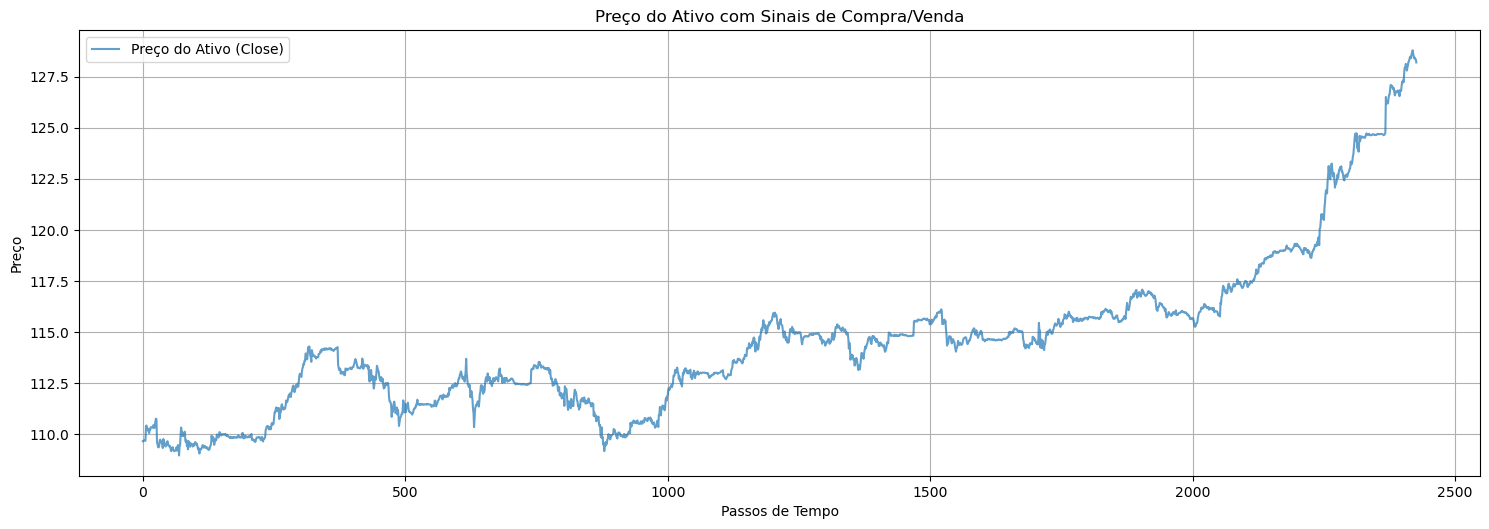

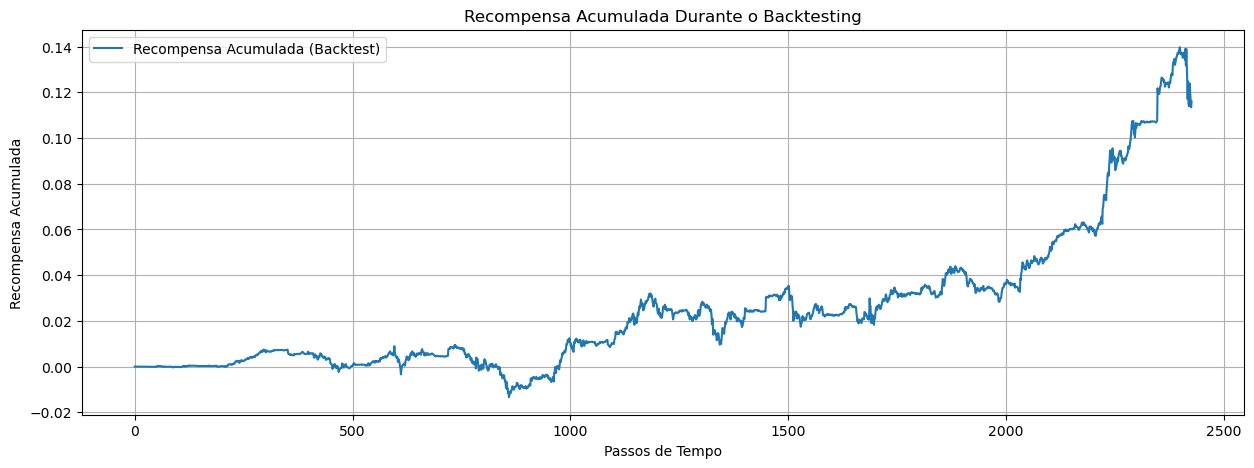

Recompensa total acumulada no backtest: 0.1160074919462204


In [35]:
if modelo_carregado and backtest_env:
    # --- 2. Preparar para Coletar Dados ---
    obs = backtest_env.reset()
    done = False

    portfolio_values = []
    buy_signals_idx = []
    sell_signals_idx = []
    actual_rewards = [] # Recompensas reais do ambiente, não normalizadas

    # Supondo que seu test_df_pd tem uma coluna de preço, ex: 'Close'
    # para plotar junto com os sinais
    precos_teste = test_df_pd['Close'].values[-len(test_df_pd) + modelo_carregado.n_steps -1:] # Ajuste o índice conforme necessário

    current_step_in_episode = 0

    # --- 3. Executar o Agente e Coletar Dados ---
    # Execute por um número de passos ou até o final do dataset de teste
    num_backtest_steps = len(test_df_pd) - 1 # Ou um valor menor para um backtest mais curto

    print(f"Iniciando backtesting por {num_backtest_steps} passos...")

    for i in range(num_backtest_steps):
        action, _states = modelo_carregado.predict(obs, deterministic=True)
        obs, reward, done, info_list = backtest_env.step(action)
        info = info_list[0] # DummyVecEnv retorna uma lista de infos

        actual_rewards.append(reward[0]) # reward também é uma lista/array com DummyVecEnv

        # Supondo que seu 'info' contenha esses dados:
        if 'portfolio_value' in info:
            portfolio_values.append(info['portfolio_value'])

        # Exemplo: Supondo que a ação 1 é COMPRAR e a ação 2 é VENDER
        # E que seu ambiente retorna a ação efetivamente tomada ou um sinal
        # Adapte isso à sua definição de espaço de ação e ao que 'info' retorna
        if 'trade_type' in info:
            if info['trade_type'] == 'BUY':
                buy_signals_idx.append(i) # Salva o índice do passo (ou data)
            elif info['trade_type'] == 'SELL':
                sell_signals_idx.append(i)
        elif 'action_taken' in info: # Alternativa se info tem a ação
             if info['action_taken'] == 1: # Exemplo para COMPRAR
                 buy_signals_idx.append(i)
             elif info['action_taken'] == 2: # Exemplo para VENDER
                 sell_signals_idx.append(i)


        if done:
            print(f"Episódio finalizado no passo {i}.")
            # Se você quiser continuar por múltiplos episódios no dataset de teste:
            # obs = backtest_env.reset()
            # current_step_in_episode = 0
            # Ou pare se for um backtest de um único "passe":
            break

        current_step_in_episode += 1
        if (i + 1) % 1000 == 0:
            print(f"Backtesting: passo {i+1}/{num_backtest_steps}")

    backtest_env.close()
    print("Backtesting finalizado.")

    # --- 4. Visualizar os Resultados ---
    print("Gerando visualizações...")
    num_collected_points = len(portfolio_values) if portfolio_values else len(actual_rewards)

    if num_collected_points > 0:
        precos_plot = test_df_pd['Close'].iloc[:num_collected_points].values

        plt.figure(figsize=(15, 10))

        # Plot do Valor da Carteira
        if portfolio_values:
            plt.subplot(2, 1, 1)
            plt.plot(portfolio_values, label='Valor da Carteira')
            plt.title('Evolução do Valor da Carteira Durante o Backtesting')
            plt.xlabel('Passos de Tempo')
            plt.ylabel('Valor da Carteira')
            plt.legend()
            plt.grid(True)

        # Plot de Preços com Sinais de Compra/Venda
        # (Certifique-se de que precos_plot tem o mesmo comprimento que o período de backtest)
        plt.subplot(2, 1, 2)
        plt.plot(precos_plot, label='Preço do Ativo (Close)', alpha=0.7)

        # Plotar os sinais. É importante que os índices em buy_signals_idx e sell_signals_idx
        # correspondam aos índices do array precos_plot.
        if buy_signals_idx:
            plt.scatter([idx for idx in buy_signals_idx if idx < len(precos_plot)],
                        precos_plot[[idx for idx in buy_signals_idx if idx < len(precos_plot)]],
                        label='Compra', marker='^', color='green', s=100, alpha=1)
        if sell_signals_idx:
            plt.scatter([idx for idx in sell_signals_idx if idx < len(precos_plot)],
                        precos_plot[[idx for idx in sell_signals_idx if idx < len(precos_plot)]],
                        label='Venda', marker='v', color='red', s=100, alpha=1)

        plt.title('Preço do Ativo com Sinais de Compra/Venda')
        plt.xlabel('Passos de Tempo')
        plt.ylabel('Preço')
        plt.legend()
        plt.grid(True)

        plt.tight_layout()
        plt.show()

        # Plot de Recompensas Acumuladas
        if actual_rewards:
            plt.figure(figsize=(15, 5))
            cumulative_rewards = pd.Series(actual_rewards).cumsum()
            plt.plot(cumulative_rewards, label='Recompensa Acumulada (Backtest)')
            plt.title('Recompensa Acumulada Durante o Backtesting')
            plt.xlabel('Passos de Tempo')
            plt.ylabel('Recompensa Acumulada')
            plt.legend()
            plt.grid(True)
            plt.show()
            print(f"Recompensa total acumulada no backtest: {cumulative_rewards.iloc[-1]}")

    else:
        print("Nenhum dado foi coletado para plotagem.")
else:
    print("Não foi possível carregar o modelo ou preparar o ambiente para o backtesting.")

In [39]:
import numpy as np
import polars as pl
from backtesting import Backtest, Strategy
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from env.trading_env import CustomTradingEnv

# janela do ambiente
window_size = 20

class RLStrategy(Strategy):
    def init(self):
        # Carrega o modelo e o normalizador
        self.model = PPO.load("models/best/ppo_trading_best.zip")

        # Converte DataFrame pandas → Polars para o backtest
        df_polars = pl.from_pandas(self.data.df.reset_index())

        # Cria DummyVecEnv só para carregar o VecNormalize
        dummy_env = DummyVecEnv([lambda: CustomTradingEnv(
            df_polars,
            features=feature_names,
            window_size=window_size
        )])

        self.vecnorm = VecNormalize.load(
            "models/best/vecnormalize_trading_best.pkl",
            dummy_env
        )
        self.model.set_env(self.vecnorm)

    def next(self):
        # Aguarda ter pelo menos window_size barras
        if len(self.data) < window_size:
            return

        # 1) Pega janela de features (20, n_features)
        df_window = self.data.df[feature_names]
        window = df_window.iloc[-window_size:].values.astype(np.float32)

        # 2) Cria coluna de posição (20, 1): 1.0 se estiver posicionado, 0.0 caso contrário
        pos = np.full(
            (window_size, 1),
            1.0 if self.position else 0.0,
            dtype=np.float32
        )

        # 3) Concatena e achata para vetor de tamanho 20*(n_features+1)=300
        obs = np.hstack((window, pos)).flatten()    # shape (300,)
        obs = obs.reshape(1, -1)                    # shape (1, 300)

        # 4) Chama a predição
        action_arr, _ = self.model.predict(obs, deterministic=True)
        action = int(action_arr[0])  # extrai scalar

        # 5) Executa lógica de compra/venda
        if action == 1 and not self.position:
            self.buy()
        elif action == 2 and self.position:
            self.position.close()

# Prepara o DataFrame de teste para o backtest
pdf_test = test_df_pd.copy()
pdf_test.index.name = "date"

# --- Executa o backtest ---
bt = Backtest(
    pdf_test,
    RLStrategy,
    cash=100_000,
    commission=0.001,
    trade_on_close=True
)

# Roda e plota
stats = bt.run()
bt.plot()
print(stats)

# --- Extrai a curva de equity do objeto stats ---
# stats é um pd.Series onde a chave '_equity_curve' guarda um DataFrame
equity_df = stats['_equity_curve']       # DataFrame com colunas ['Equity', 'DrawdownPct', 'DrawdownDuration']
cumret = equity_df['Equity']             # Série temporal da Equity

# (Opcional) Se você quiser, converte em retorno relativo:
# rel_ret = cumret / cumret.iloc[0] - 1

# Agora 'cumret' é um pd.Series indexado em datas, com a evolução do seu patrimônio
pdf_test = df

Backtest.run:   0%|          | 0/2447 [00:00<?, ?bar/s]

Start                     2020-08-04 23:30:00
End                       2020-08-24 14:40:00
Duration                     19 days 15:10:00
Exposure Time [%]                    75.69444
Equity Final [$]                   61493.2211
Equity Peak [$]                    100015.566
Commissions [$]                   46713.62579
Return [%]                          -38.50678
Buy & Hold Return [%]                14.34619
Return (Ann.) [%]                   -99.97167
Volatility (Ann.) [%]                 0.00913
CAGR [%]                            -99.80531
Sharpe Ratio                     -10949.96308
Sortino Ratio                        -1.62951
Calmar Ratio                         -2.55987
Alpha [%]                           -46.41309
Beta                                  0.55111
Max. Drawdown [%]                   -39.05346
Avg. Drawdown [%]                   -39.05346
Max. Drawdown Duration       19 days 05:15:00
Avg. Drawdown Duration       19 days 05:15:00
# Trades                          

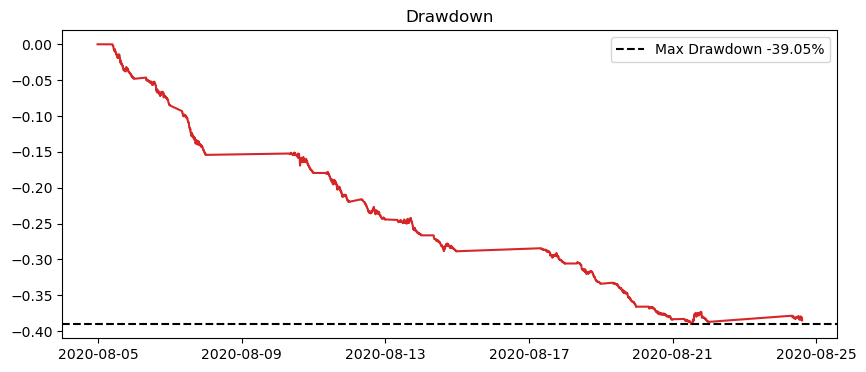

In [40]:
cum = cumret
running_max = cum.cummax()
drawdown = (cum - running_max) / running_max

plt.figure(figsize=(10,4))
plt.plot(drawdown, color='tab:red')
plt.title("Drawdown")
plt.axhline(drawdown.min(), color='black', linestyle='--',
            label=f"Max Drawdown {drawdown.min():.2%}")
plt.legend()
plt.show()

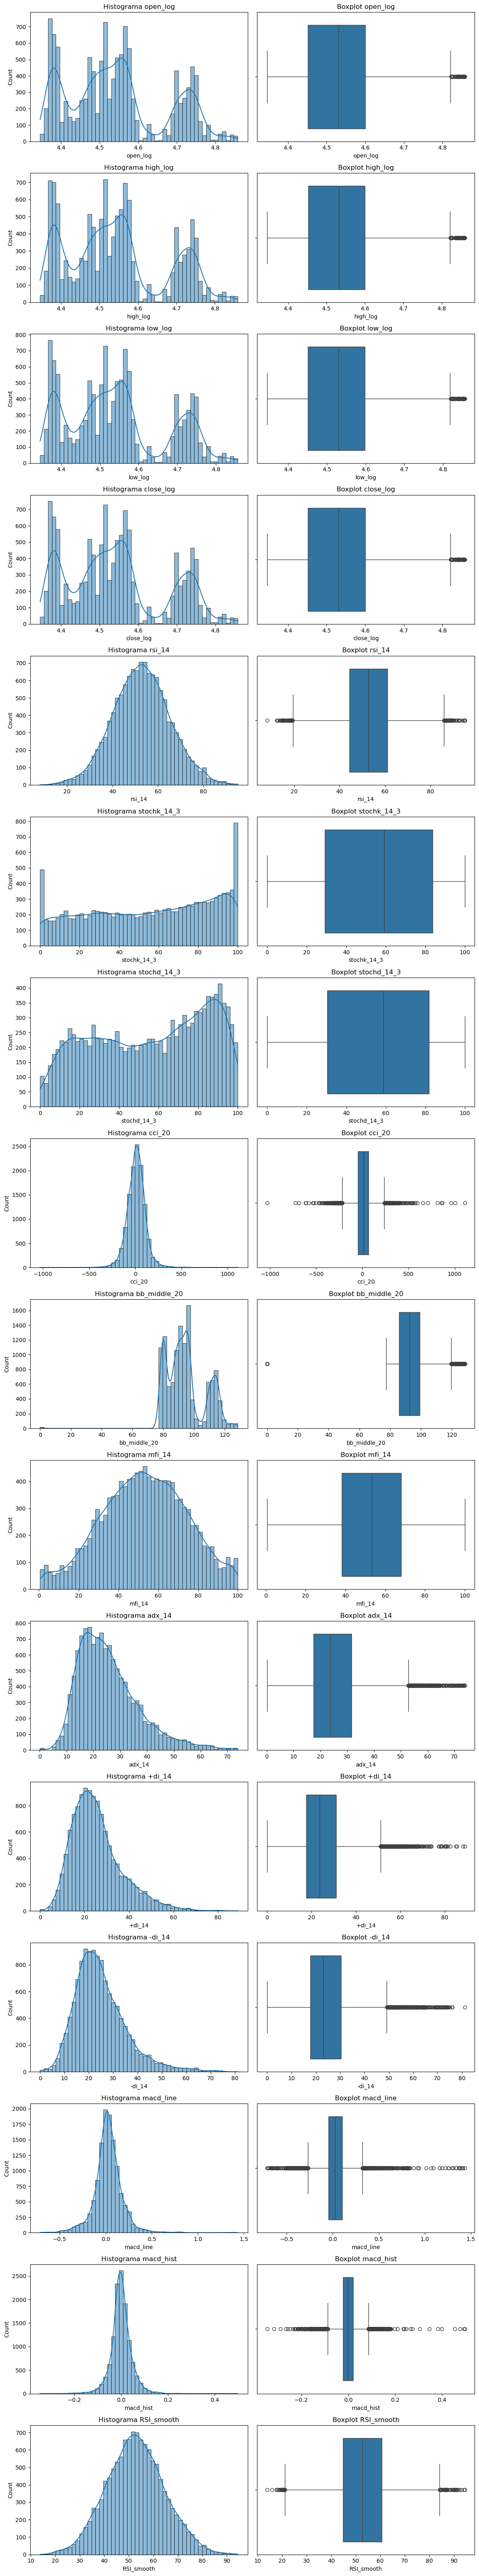

In [41]:
# selecione só as colunas de indicadores
ind_cols = [c for c in df.columns if c not in ['date','open','high','low','close','volume']]
pdf = df[ind_cols]

# histograma e boxplot lado a lado
fig, axes = plt.subplots(len(ind_cols),2, figsize=(12,4*len(ind_cols)))
for i, col in enumerate(ind_cols):
    sns.histplot(pdf[col], bins=50, ax=axes[i,0], kde=True)
    axes[i,0].set_title(f'Histograma {col}')
    sns.boxplot(x=pdf[col], ax=axes[i,1])
    axes[i,1].set_title(f'Boxplot {col}')
plt.tight_layout()
plt.show()